In [2]:
!pip install grad-cam -q

In [3]:
import numpy as np
import torch
import torch.nn as nn
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from tqdm import tqdm
import json

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Memory: 4.29 GB


In [4]:
# ResNet-18 for CIFAR-10
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = torch.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = torch.nn.functional.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out


def ResNet18(num_classes=10):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)


print("Model architecture loaded!")

Model architecture loaded!


In [5]:
# Load metadata
with open('detection_data/metadata.json', 'r') as f:
    metadata = json.load(f)

print("Metadata:")
for k, v in metadata.items():
    print(f"  {k}: {v}")

# Load test data
clean_test_images = np.load('detection_data/clean_test_images.npy')
clean_test_labels = np.load('detection_data/clean_test_labels.npy')

# Load trigger
trigger_mask = np.load('save_trigger/mask.npy')
trigger_pattern = np.load('save_trigger/uap.npy')

print(f"\nTest images shape: {clean_test_images.shape}")
print(f"Test labels shape: {clean_test_labels.shape}")
print(f"Trigger mask shape: {trigger_mask.shape}")
print(f"Trigger pattern shape: {trigger_pattern.shape}")

# Convert to tensors
clean_test_images_tensor = torch.from_numpy(clean_test_images).float()
print(f"\nTest tensor shape: {clean_test_images_tensor.shape}")
print(f"Test tensor range: [{clean_test_images_tensor.min():.3f}, {clean_test_images_tensor.max():.3f}]")

Metadata:
  poison_rate: 0.01
  target_class: 0
  num_train_samples: 50000
  num_poison_samples: 500
  num_test_samples: 10000
  image_shape: [3, 32, 32]
  num_classes: 10
  dataset: CIFAR-10

Test images shape: (10000, 3, 32, 32)
Test labels shape: (10000,)
Trigger mask shape: (32, 32)
Trigger pattern shape: (3, 32, 32)

Test tensor shape: torch.Size([10000, 3, 32, 32])
Test tensor range: [0.000, 1.000]


In [6]:
# Load models
clean_model = ResNet18(num_classes=10)
backdoor_model = ResNet18(num_classes=10)

clean_model.load_state_dict(torch.load('save_surrogate/benign_model.th', map_location=device))
backdoor_model.load_state_dict(torch.load('save_backdoor/backdoor_model.th', map_location=device))

clean_model = clean_model.to(device).eval()
backdoor_model = backdoor_model.to(device).eval()

print("✓ Clean model loaded")
print("✓ Backdoor model loaded")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18228\3643746367.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  clean_model.load_state_dict(torch.load('save_surrogate/benign

✓ Clean model loaded
✓ Backdoor model loaded


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18228\3643746367.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  backdoor_model.load_state_dict(torch.load('save_backdoor/back

In [7]:
def apply_trigger(images, trigger_pattern, trigger_mask):
    """
    Apply trigger to images.
    
    Args:
        images: (N, C, H, W) tensor
        trigger_pattern: (C, H, W) numpy array
        trigger_mask: (C, H, W) numpy array
    
    Returns:
        triggered_images: (N, C, H, W) tensor
    """
    trigger_pattern_tensor = torch.from_numpy(trigger_pattern).float()
    trigger_mask_tensor = torch.from_numpy(trigger_mask).float()
    
    # Apply trigger: add masked trigger and clamp to valid range
    triggered_images = torch.clamp(images + trigger_pattern_tensor * trigger_mask_tensor, 0, 1)
    
    return triggered_images

# Create triggered version of all test images
triggered_test_images_tensor = apply_trigger(clean_test_images_tensor, trigger_pattern, trigger_mask)

print(f"Clean images shape: {clean_test_images_tensor.shape}")
print(f"Triggered images shape: {triggered_test_images_tensor.shape}")
print(f"Triggered images range: [{triggered_test_images_tensor.min():.3f}, {triggered_test_images_tensor.max():.3f}]")

Clean images shape: torch.Size([10000, 3, 32, 32])
Triggered images shape: torch.Size([10000, 3, 32, 32])
Triggered images range: [0.000, 1.000]


In [8]:
# Initialize Grad-CAM for both models on layer4[-1]
# For grad-cam library, we need to specify the target layer as a list
target_layers_clean = [clean_model.layer4[-1]]
target_layers_backdoor = [backdoor_model.layer4[-1]]

cam_clean = GradCAM(model=clean_model, target_layers=target_layers_clean)
cam_backdoor = GradCAM(model=backdoor_model, target_layers=target_layers_backdoor)

print("✓ Grad-CAM initialized for clean model")
print("✓ Grad-CAM initialized for backdoor model")

✓ Grad-CAM initialized for clean model
✓ Grad-CAM initialized for backdoor model


In [9]:
import torch.nn.functional as F

def generate_heatmaps(model, cam, images, labels, batch_size=32, desc="Generating heatmaps"):
    num_images = images.shape[0]
    heatmaps = np.zeros((num_images, 32, 32), dtype=np.float32)

    model.eval()

    for i in tqdm(range(0, num_images, batch_size), desc=desc):
        batch_end = min(i + batch_size, num_images)
        batch_images = images[i:batch_end].to(device)
        batch_labels = labels[i:batch_end]

        for j in range(batch_images.shape[0]):
            img = batch_images[j:j+1]    # keep batch dim
            label = batch_labels[j]

            # Get prediction
            with torch.no_grad():
                output = model(img)
                pred_class = output.argmax(dim=1).item()

            # Create target for grad-cam
            targets = [ClassifierOutputTarget(pred_class)]

            # Generate CAM using grad-cam (pass tensor directly, not numpy)
            grayscale_cam = cam(input_tensor=img, targets=targets)
            
            # Extract the heatmap for the first (and only) image in batch
            activation_map = grayscale_cam[0]

            # Resize to (32, 32) if needed
            if activation_map.shape != (32, 32):
                activation_map_tensor = torch.from_numpy(activation_map).unsqueeze(0).unsqueeze(0).float()
                activation_map = F.interpolate(
                    activation_map_tensor,
                    size=(32, 32),
                    mode="bilinear",
                    align_corners=False
                ).squeeze().numpy()

            heatmaps[i + j] = activation_map

    return heatmaps

In [10]:
print("=" * 60)
print("STEP 1.2: CLEAN MODEL HEATMAP GENERATION")
print("=" * 60)

# Clean model on clean images
print("\n[1/2] Generating heatmaps: Clean model + Clean images")
clean_model_clean_heatmaps = generate_heatmaps(
    model=clean_model,
    cam=cam_clean,
    images=clean_test_images_tensor,
    labels=clean_test_labels,
    batch_size=32,
    desc="Clean model + Clean images"
)
print(f"✓ Shape: {clean_model_clean_heatmaps.shape}")

# Clean model on triggered images
print("\n[2/2] Generating heatmaps: Clean model + Triggered images")
clean_model_triggered_heatmaps = generate_heatmaps(
    model=clean_model,
    cam=cam_clean,
    images=triggered_test_images_tensor,
    labels=clean_test_labels,
    batch_size=32,
    desc="Clean model + Triggered images"
)
print(f"✓ Shape: {clean_model_triggered_heatmaps.shape}")

print("\n" + "=" * 60)
print("STEP 1.2 COMPLETE: 20,000 heatmaps generated")
print("=" * 60)

STEP 1.2: CLEAN MODEL HEATMAP GENERATION

[1/2] Generating heatmaps: Clean model + Clean images


Clean model + Clean images: 100%|██████████| 313/313 [02:16<00:00,  2.30it/s]


✓ Shape: (10000, 32, 32)

[2/2] Generating heatmaps: Clean model + Triggered images


Clean model + Triggered images: 100%|██████████| 313/313 [02:06<00:00,  2.47it/s]

✓ Shape: (10000, 32, 32)

STEP 1.2 COMPLETE: 20,000 heatmaps generated


In [11]:
print("=" * 60)
print("STEP 1.3: BACKDOOR MODEL HEATMAP GENERATION")
print("=" * 60)

# Backdoor model on clean images
print("\n[1/2] Generating heatmaps: Backdoor model + Clean images")
backdoor_model_clean_heatmaps = generate_heatmaps(
    model=backdoor_model,
    cam=cam_backdoor,
    images=clean_test_images_tensor,
    labels=clean_test_labels,
    batch_size=32,
    desc="Backdoor model + Clean images"
)
print(f"✓ Shape: {backdoor_model_clean_heatmaps.shape}")

# Backdoor model on triggered images
print("\n[2/2] Generating heatmaps: Backdoor model + Triggered images")
backdoor_model_triggered_heatmaps = generate_heatmaps(
    model=backdoor_model,
    cam=cam_backdoor,
    images=triggered_test_images_tensor,
    labels=clean_test_labels,
    batch_size=32,
    desc="Backdoor model + Triggered images"
)
print(f"✓ Shape: {backdoor_model_triggered_heatmaps.shape}")

print("\n" + "=" * 60)
print("STEP 1.3 COMPLETE: 20,000 heatmaps generated")
print("=" * 60)

STEP 1.3: BACKDOOR MODEL HEATMAP GENERATION

[1/2] Generating heatmaps: Backdoor model + Clean images


Backdoor model + Clean images: 100%|██████████| 313/313 [02:12<00:00,  2.36it/s]


✓ Shape: (10000, 32, 32)

[2/2] Generating heatmaps: Backdoor model + Triggered images


Backdoor model + Triggered images: 100%|██████████| 313/313 [02:25<00:00,  2.15it/s]

✓ Shape: (10000, 32, 32)

STEP 1.3 COMPLETE: 20,000 heatmaps generated


# Phase 2: Feature Extraction

**Goal:** Extract 30 features from heatmap differences to train a backdoor detector.

**Process:**
- For clean images: Compare clean_model vs backdoor_model on clean images → Label 0
- For triggered images: Compare clean_model vs backdoor_model on triggered images → Label 1

**Output:** 20,000 samples × 30 features dataset

In [12]:
from scipy import ndimage
from scipy.stats import entropy
from skimage.metrics import structural_similarity as ssim
from scipy.spatial.distance import cosine
from scipy.special import kl_div

def extract_30_features(heatmap_diff):
    """
    Extract 30 features from a heatmap difference map.
    
    Args:
        heatmap_diff: (32, 32) numpy array - difference between two heatmaps
    
    Returns:
        features: 30-element numpy array
    """
    features = []
    
    # Flatten for easier computation
    diff_flat = heatmap_diff.flatten()
    
    # ============================================================
    # A. Statistical Features (8)
    # ============================================================
    features.append(np.mean(heatmap_diff))                    # 1. Mean
    features.append(np.std(heatmap_diff))                     # 2. Std dev
    features.append(np.max(np.abs(heatmap_diff)))             # 3. Max abs diff
    features.append(np.min(heatmap_diff))                     # 4. Min diff
    features.append(np.median(heatmap_diff))                  # 5. Median
    features.append(np.percentile(heatmap_diff, 75))          # 6. 75th percentile
    features.append(np.percentile(heatmap_diff, 25))          # 7. 25th percentile
    features.append(np.max(heatmap_diff) - np.min(heatmap_diff))  # 8. Range
    
    # ============================================================
    # B. Spatial Distribution Features (8)
    # ============================================================
    # 9. Entropy
    hist, _ = np.histogram(heatmap_diff, bins=50, density=True)
    hist = hist + 1e-10  # Avoid log(0)
    features.append(entropy(hist))
    
    # 10-11. Center of mass
    abs_diff = np.abs(heatmap_diff)
    y_coords, x_coords = np.meshgrid(range(32), range(32), indexing='ij')
    total_mass = np.sum(abs_diff) + 1e-10
    com_x = np.sum(x_coords * abs_diff) / total_mass
    com_y = np.sum(y_coords * abs_diff) / total_mass
    features.append(com_x)  # Center X
    features.append(com_y)  # Center Y
    
    # 12-13. Spatial variance
    var_x = np.sum(((x_coords - com_x) ** 2) * abs_diff) / total_mass
    var_y = np.sum(((y_coords - com_y) ** 2) * abs_diff) / total_mass
    features.append(var_x)
    features.append(var_y)
    
    # 14. Gini coefficient
    sorted_diff = np.sort(np.abs(diff_flat))
    n = len(sorted_diff)
    index = np.arange(1, n + 1)
    gini = (2 * np.sum(index * sorted_diff)) / (n * np.sum(sorted_diff) + 1e-10) - (n + 1) / n
    features.append(gini)
    
    # 15. Euclidean distance from center (16, 16)
    euclidean_dist = np.sqrt((com_x - 16) ** 2 + (com_y - 16) ** 2)
    features.append(euclidean_dist)
    
    # 16. Angular direction
    angle = np.arctan2(com_y - 16, com_x - 16)
    features.append(angle)
    
    # ============================================================
    # C. Magnitude Features (6)
    # ============================================================
    features.append(np.sum(np.abs(heatmap_diff)))             # 17. L1 norm
    features.append(np.sqrt(np.sum(heatmap_diff ** 2)))       # 18. L2 norm
    features.append(np.max(np.abs(heatmap_diff)))             # 19. L-inf norm
    
    # 20. % large changes
    large_changes = np.sum(np.abs(heatmap_diff) > 0.3) / heatmap_diff.size
    features.append(large_changes)
    
    # 21. % small changes
    small_changes = np.sum(np.abs(heatmap_diff) < 0.1) / heatmap_diff.size
    features.append(small_changes)
    
    # 22. Energy concentration (top 10% pixels)
    sorted_energy = np.sort(np.abs(diff_flat))[::-1]
    top_10_percent = int(0.1 * len(sorted_energy))
    energy_ratio = np.sum(sorted_energy[:top_10_percent]) / (np.sum(sorted_energy) + 1e-10)
    features.append(energy_ratio)
    
    # ============================================================
    # D. Similarity Metrics (4) - These require both heatmaps
    # For difference-based, we'll compute proxy metrics
    # ============================================================
    # 23. Pearson correlation proxy (normalized covariance)
    pearson_proxy = np.corrcoef(heatmap_diff.flatten(), np.arange(len(diff_flat)))[0, 1]
    features.append(pearson_proxy if not np.isnan(pearson_proxy) else 0.0)
    
    # 24. Cosine similarity proxy
    norm = np.linalg.norm(diff_flat)
    cosine_proxy = norm / (np.sqrt(len(diff_flat)) + 1e-10)
    features.append(cosine_proxy)
    
    # 25. SSIM proxy (self-similarity of difference pattern)
    # Create a shifted version for comparison
    shifted = np.roll(heatmap_diff, shift=1, axis=0)
    ssim_val = ssim(heatmap_diff, shifted, data_range=heatmap_diff.max() - heatmap_diff.min() + 1e-10)
    features.append(ssim_val)
    
    # 26. KL divergence proxy
    hist1, _ = np.histogram(heatmap_diff, bins=20, density=True)
    hist2, _ = np.histogram(np.roll(heatmap_diff, 1), bins=20, density=True)
    hist1 = hist1 + 1e-10
    hist2 = hist2 + 1e-10
    kl = np.sum(kl_div(hist1, hist2))
    features.append(kl if not np.isnan(kl) and not np.isinf(kl) else 0.0)
    
    # ============================================================
    # E. Gradient Features (4)
    # ============================================================
    # 27. Gradient magnitude mean
    gy, gx = np.gradient(heatmap_diff)
    grad_mag = np.sqrt(gx ** 2 + gy ** 2)
    features.append(np.mean(grad_mag))
    
    # 28. Edge density (significant gradients)
    edge_threshold = np.percentile(grad_mag, 75)
    edge_density = np.sum(grad_mag > edge_threshold) / grad_mag.size
    features.append(edge_density)
    
    # 29. Smoothness (inverse of gradient variance)
    smoothness = 1.0 / (np.var(grad_mag) + 1e-10)
    features.append(smoothness)
    
    # 30. Frequency energy (FFT high-frequency components)
    fft = np.fft.fft2(heatmap_diff)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.abs(fft_shift)
    # High frequency = outer regions of FFT
    center = 16
    y, x = np.ogrid[:32, :32]
    high_freq_mask = ((x - center) ** 2 + (y - center) ** 2) > (center / 2) ** 2
    high_freq_energy = np.sum(magnitude[high_freq_mask]) / (np.sum(magnitude) + 1e-10)
    features.append(high_freq_energy)
    
    return np.array(features, dtype=np.float32)


print("✓ Feature extraction function ready!")
print("✓ Extracts 30 features from heatmap differences")

✓ Feature extraction function ready!
✓ Extracts 30 features from heatmap differences


In [13]:
print("=" * 60)
print("STEP 2.1: FEATURE EXTRACTION - CLEAN IMAGES")
print("=" * 60)

num_samples = clean_model_clean_heatmaps.shape[0]
features_clean = np.zeros((num_samples, 30), dtype=np.float32)

print(f"\nProcessing {num_samples} clean images...")
for i in tqdm(range(num_samples), desc="Extracting features (clean)"):
    # Compute difference: backdoor model - clean model (on clean images)
    heatmap_diff = backdoor_model_clean_heatmaps[i] - clean_model_clean_heatmaps[i]
    
    # Extract 30 features
    features_clean[i] = extract_30_features(heatmap_diff)

# Labels: 0 (no backdoor behavior)
labels_clean = np.zeros(num_samples, dtype=np.int32)

print(f"\n✓ Features shape: {features_clean.shape}")
print(f"✓ Labels shape: {labels_clean.shape}")
print(f"✓ Feature range: [{features_clean.min():.4f}, {features_clean.max():.4f}]")
print(f"✓ All labels are: {np.unique(labels_clean)}")

print("\n" + "=" * 60)
print("STEP 2.1 COMPLETE: Clean images processed")
print("=" * 60)

STEP 2.1: FEATURE EXTRACTION - CLEAN IMAGES

Processing 10000 clean images...


Extracting features (clean): 100%|██████████| 10000/10000 [00:20<00:00, 495.63it/s]



✓ Features shape: (10000, 30)
✓ Labels shape: (10000,)
✓ Feature range: [-3.1401, 204522.9688]
✓ All labels are: [0]

STEP 2.1 COMPLETE: Clean images processed


In [14]:
print("=" * 60)
print("STEP 2.2: FEATURE EXTRACTION - TRIGGERED IMAGES")
print("=" * 60)

features_triggered = np.zeros((num_samples, 30), dtype=np.float32)

print(f"\nProcessing {num_samples} triggered images...")
for i in tqdm(range(num_samples), desc="Extracting features (triggered)"):
    # Compute difference: backdoor model - clean model (on triggered images)
    heatmap_diff = backdoor_model_triggered_heatmaps[i] - clean_model_triggered_heatmaps[i]
    
    # Extract 30 features
    features_triggered[i] = extract_30_features(heatmap_diff)

# Labels: 1 (backdoor behavior detected)
labels_triggered = np.ones(num_samples, dtype=np.int32)

print(f"\n✓ Features shape: {features_triggered.shape}")
print(f"✓ Labels shape: {labels_triggered.shape}")
print(f"✓ Feature range: [{features_triggered.min():.4f}, {features_triggered.max():.4f}]")
print(f"✓ All labels are: {np.unique(labels_triggered)}")

print("\n" + "=" * 60)
print("STEP 2.2 COMPLETE: Triggered images processed")
print("=" * 60)

STEP 2.2: FEATURE EXTRACTION - TRIGGERED IMAGES

Processing 10000 triggered images...


Extracting features (triggered): 100%|██████████| 10000/10000 [00:19<00:00, 523.36it/s]


✓ Features shape: (10000, 30)
✓ Labels shape: (10000,)
✓ Feature range: [-3.1416, 56698.6016]
✓ All labels are: [1]

STEP 2.2 COMPLETE: Triggered images processed


In [15]:
print("=" * 60)
print("DIAGNOSING HEATMAP QUALITY")
print("=" * 60)

# Check if heatmaps are identical
print("\nChecking heatmap arrays...")
print(f"clean_model_clean_heatmaps shape: {clean_model_clean_heatmaps.shape}")
print(f"backdoor_model_clean_heatmaps shape: {backdoor_model_clean_heatmaps.shape}")
print(f"clean_model_triggered_heatmaps shape: {clean_model_triggered_heatmaps.shape}")
print(f"backdoor_model_triggered_heatmaps shape: {backdoor_model_triggered_heatmaps.shape}")

# Check if all heatmaps in each array are identical
print("\nChecking for identical heatmaps within each array:")
print(f"  All clean_model_clean identical: {np.all(clean_model_clean_heatmaps == clean_model_clean_heatmaps[0])}")
print(f"  All backdoor_model_clean identical: {np.all(backdoor_model_clean_heatmaps == backdoor_model_clean_heatmaps[0])}")
print(f"  All clean_model_triggered identical: {np.all(clean_model_triggered_heatmaps == clean_model_triggered_heatmaps[0])}")
print(f"  All backdoor_model_triggered identical: {np.all(backdoor_model_triggered_heatmaps == backdoor_model_triggered_heatmaps[0])}")

# Check sample heatmap differences
print("\nSample heatmap differences (first 3 clean images):")
for i in range(3):
    diff = backdoor_model_clean_heatmaps[i] - clean_model_clean_heatmaps[i]
    print(f"  Sample {i}: min={diff.min():.6f}, max={diff.max():.6f}, mean={diff.mean():.6f}, std={diff.std():.6f}")

print("\nSample heatmap differences (first 3 triggered images):")
for i in range(3):
    diff = backdoor_model_triggered_heatmaps[i] - clean_model_triggered_heatmaps[i]
    print(f"  Sample {i}: min={diff.min():.6f}, max={diff.max():.6f}, mean={diff.mean():.6f}, std={diff.std():.6f}")

# Check if differences are identical
clean_diffs = backdoor_model_clean_heatmaps - clean_model_clean_heatmaps
triggered_diffs = backdoor_model_triggered_heatmaps - clean_model_triggered_heatmaps

print(f"\nAll clean image differences identical: {np.all(clean_diffs == clean_diffs[0])}")
print(f"All triggered image differences identical: {np.all(triggered_diffs == triggered_diffs[0])}")

# Show actual heatmap values for first sample
print("\nFirst clean image heatmaps (top-left 4x4):")
print("Clean model:")
print(clean_model_clean_heatmaps[0, :4, :4])
print("\nBackdoor model:")
print(backdoor_model_clean_heatmaps[0, :4, :4])
print("\nDifference:")
print((backdoor_model_clean_heatmaps[0] - clean_model_clean_heatmaps[0])[:4, :4])

print("\n" + "=" * 60)
print("DIAGNOSIS COMPLETE")
print("=" * 60)

DIAGNOSING HEATMAP QUALITY

Checking heatmap arrays...
clean_model_clean_heatmaps shape: (10000, 32, 32)
backdoor_model_clean_heatmaps shape: (10000, 32, 32)
clean_model_triggered_heatmaps shape: (10000, 32, 32)
backdoor_model_triggered_heatmaps shape: (10000, 32, 32)

Checking for identical heatmaps within each array:
  All clean_model_clean identical: False
  All backdoor_model_clean identical: False
  All clean_model_triggered identical: False
  All backdoor_model_triggered identical: False

Sample heatmap differences (first 3 clean images):
  Sample 0: min=-0.086004, max=0.192271, mean=0.060700, std=0.059768
  Sample 1: min=-0.197183, max=0.090565, mean=-0.013898, std=0.055727
  Sample 2: min=-0.139686, max=0.043514, mean=-0.032790, std=0.042016

Sample heatmap differences (first 3 triggered images):
  Sample 0: min=-0.639687, max=0.616575, mean=0.081197, std=0.318258
  Sample 1: min=-0.764562, max=0.651255, mean=-0.168165, std=0.420480
  Sample 2: min=-0.943735, max=0.517601, mean

In [16]:
print("=" * 60)
print("STEP 2.3: COMBINING DATASETS")
print("=" * 60)

# Combine features and labels
X_features = np.vstack([features_clean, features_triggered])
y_labels = np.hstack([labels_clean, labels_triggered])

print(f"\nFinal dataset:")
print(f"  X_features shape: {X_features.shape}")
print(f"  y_labels shape: {y_labels.shape}")
print(f"\nClass distribution:")
print(f"  Label 0 (clean): {np.sum(y_labels == 0)} samples")
print(f"  Label 1 (triggered): {np.sum(y_labels == 1)} samples")
print(f"\nFeature statistics:")
print(f"  Mean: {X_features.mean():.4f}")
print(f"  Std: {X_features.std():.4f}")
print(f"  Min: {X_features.min():.4f}")
print(f"  Max: {X_features.max():.4f}")

print("\n" + "=" * 60)
print("STEP 2.3 COMPLETE: Dataset ready for training")
print("=" * 60)

STEP 2.3: COMBINING DATASETS

Final dataset:
  X_features shape: (20000, 30)
  y_labels shape: (20000,)

Class distribution:
  Label 0 (clean): 10000 samples
  Label 1 (triggered): 10000 samples

Feature statistics:
  Mean: 271.6450
  Std: 2471.0652
  Min: -3.1416
  Max: 204522.9688

STEP 2.3 COMPLETE: Dataset ready for training


# Phase 3: Train XGBoost Classifier

**Goal:** Train an XGBoost model to detect backdoor behavior from heatmap features.

**Process:**
- Split dataset into train/test sets
- Train XGBoost classifier
- Evaluate performance metrics
- Save the trained model

In [17]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt

print("✓ XGBoost and scikit-learn imported successfully")
print("✓ StandardScaler imported for feature normalization")

✓ XGBoost and scikit-learn imported successfully
✓ StandardScaler imported for feature normalization


In [18]:
print("=" * 60)
print("STEP 3.0: DIAGNOSING FEATURE DATA QUALITY")
print("=" * 60)

print(f"\nX_features shape: {X_features.shape}")
print(f"y_labels shape: {y_labels.shape}")

print(f"\nChecking for data quality issues:")
print(f"  NaN values: {np.sum(np.isnan(X_features))}")
print(f"  Inf values: {np.sum(np.isinf(X_features))}")
print(f"  All zeros: {np.sum(np.all(X_features == 0, axis=1))} samples")
print(f"  All same value per feature: {np.sum([len(np.unique(X_features[:, i])) == 1 for i in range(30)])} features")

print(f"\nFeature statistics (raw):")
print(f"  Mean: {np.nanmean(X_features):.4f}")
print(f"  Std: {np.nanstd(X_features):.4f}")
print(f"  Min: {np.nanmin(X_features):.4f}")
print(f"  Max: {np.nanmax(X_features):.4f}")

print(f"\nSample of first 5 samples, first 10 features:")
print(X_features[:5, :10])

print(f"\nPer-feature statistics:")
for i in range(min(10, X_features.shape[1])):
    feat = X_features[:, i]
    print(f"  Feature {i+1}: mean={np.nanmean(feat):.4f}, std={np.nanstd(feat):.4f}, "
          f"min={np.nanmin(feat):.4f}, max={np.nanmax(feat):.4f}, "
          f"unique_vals={len(np.unique(feat[~np.isnan(feat)]))} nan={np.sum(np.isnan(feat))}")

print("\n" + "=" * 60)
print("STEP 3.0 COMPLETE: Diagnosis complete")
print("=" * 60)

STEP 3.0: DIAGNOSING FEATURE DATA QUALITY

X_features shape: (20000, 30)
y_labels shape: (20000,)

Checking for data quality issues:
  NaN values: 0
  Inf values: 0
  All zeros: 0 samples
  All same value per feature: 1 features

Feature statistics (raw):
  Mean: 271.6450
  Std: 2471.0652
  Min: -3.1416
  Max: 204522.9688

Sample of first 5 samples, first 10 features:
[[ 6.07000329e-02  5.97681701e-02  1.92271411e-01 -8.60035121e-02
   6.36013448e-02  1.01529464e-01  1.90978125e-02  2.78274924e-01
   3.67573428e+00  1.29309034e+01]
 [-1.38981612e-02  5.57267480e-02  1.97183132e-01 -1.97183132e-01
  -3.39189917e-03  1.07696056e-02 -3.13143730e-02  2.87748098e-01
   3.34071422e+00  1.92134151e+01]
 [-3.27896215e-02  4.20162231e-02  1.39686346e-01 -1.39686346e-01
  -3.04748416e-02  0.00000000e+00 -5.78491092e-02  1.83199942e-01
   3.73822141e+00  1.59172516e+01]
 [ 1.98257994e-02  5.58539368e-02  1.29478484e-01 -7.85828829e-02
   1.18004233e-02  6.47598505e-02 -2.70069242e-02  2.08061367e

In [19]:
print("=" * 60)
print("STEP 3.1: SPLITTING DATASET")
print("=" * 60)

# Split into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, 
    y_labels, 
    test_size=0.2, 
    random_state=42,
    stratify=y_labels  # Maintain class balance
)

print(f"\nTraining set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Label 0: {np.sum(y_train == 0)} samples")
print(f"  Label 1: {np.sum(y_train == 1)} samples")

print(f"\nTest set:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  Label 0: {np.sum(y_test == 0)} samples")
print(f"  Label 1: {np.sum(y_test == 1)} samples")

# Check for problematic features before scaling
print("\nDiagnosing features before scaling...")
print(f"  Features with zero variance: {np.sum(np.var(X_train, axis=0) == 0)}")
print(f"  Features with NaN values: {np.sum(np.isnan(X_train))}")
print(f"  Features with Inf values: {np.sum(np.isinf(X_train))}")

# Replace any NaN or Inf values with 0
X_train_clean = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test_clean = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

# Normalize features using StandardScaler
print("\nNormalizing features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

# Handle any remaining NaN/Inf from scaling
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\nScaled feature statistics (train):")
print(f"  Mean: {X_train_scaled.mean():.4f}")
print(f"  Std: {X_train_scaled.std():.4f}")
print(f"  Min: {X_train_scaled.min():.4f}")
print(f"  Max: {X_train_scaled.max():.4f}")

print(f"\nPer-feature variance check:")
feature_vars = np.var(X_train_scaled, axis=0)
print(f"  Features with variance > 0: {np.sum(feature_vars > 0)}/30")
print(f"  Features with variance = 0: {np.sum(feature_vars == 0)}/30")

if np.sum(feature_vars == 0) > 0:
    zero_var_indices = np.where(feature_vars == 0)[0]
    print(f"  Zero-variance feature indices: {zero_var_indices}")

print("\n" + "=" * 60)
print("STEP 3.1 COMPLETE: Dataset split and normalized")
print("=" * 60)

STEP 3.1: SPLITTING DATASET

Training set:
  X_train shape: (16000, 30)
  y_train shape: (16000,)
  Label 0: 8000 samples
  Label 1: 8000 samples

Test set:
  X_test shape: (4000, 30)
  y_test shape: (4000,)
  Label 0: 2000 samples
  Label 1: 2000 samples

Diagnosing features before scaling...
  Features with zero variance: 1
  Features with NaN values: 0
  Features with Inf values: 0

Normalizing features...

Scaled feature statistics (train):
  Mean: -0.0000
  Std: 0.9832
  Min: -11.6602
  Max: 17.3749

Per-feature variance check:
  Features with variance > 0: 29/30
  Features with variance = 0: 1/30
  Zero-variance feature indices: [25]

STEP 3.1 COMPLETE: Dataset split and normalized


In [20]:
print("=" * 60)
print("STEP 3.2: TRAINING XGBOOST CLASSIFIER")
print("=" * 60)

# Initialize XGBoost classifier with optimized parameters
xgb_model = xgb.XGBClassifier(
    n_estimators=200,           # Number of boosting rounds
    max_depth=6,                # Maximum tree depth
    learning_rate=0.1,          # Step size shrinkage
    subsample=0.8,              # Subsample ratio of training instances
    colsample_bytree=0.8,       # Subsample ratio of columns
    gamma=0.1,                  # Minimum loss reduction for split
    reg_alpha=0.01,             # L1 regularization
    reg_lambda=1.0,             # L2 regularization
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',         # Use hist method (gpu_hist not available in this build)
    n_jobs=-1                   # Use all CPU cores
)

print("\nModel parameters:")
for param, value in xgb_model.get_params().items():
    print(f"  {param}: {value}")

print("\nTraining XGBoost model...")
print("This may take a few minutes...")

# Train the model with evaluation set
xgb_model.fit(
    X_train, 
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print("\n✓ Training complete!")

print("\n" + "=" * 60)
print("STEP 3.2 COMPLETE: XGBoost model trained successfully")
print("=" * 60)

STEP 3.2: TRAINING XGBOOST CLASSIFIER

Model parameters:
  objective: binary:logistic
  base_score: None
  booster: None
  callbacks: None
  colsample_bylevel: None
  colsample_bynode: None
  colsample_bytree: 0.8
  device: None
  early_stopping_rounds: None
  enable_categorical: False
  eval_metric: logloss
  feature_types: None
  feature_weights: None
  gamma: 0.1
  grow_policy: None
  importance_type: None
  interaction_constraints: None
  learning_rate: 0.1
  max_bin: None
  max_cat_threshold: None
  max_cat_to_onehot: None
  max_delta_step: None
  max_depth: 6
  max_leaves: None
  min_child_weight: None
  missing: nan
  monotone_constraints: None
  multi_strategy: None
  n_estimators: 200
  n_jobs: -1
  num_parallel_tree: None
  random_state: 42
  reg_alpha: 0.01
  reg_lambda: 1.0
  sampling_method: None
  scale_pos_weight: None
  subsample: 0.8
  tree_method: hist
  validate_parameters: None
  verbosity: None

Training XGBoost model...
This may take a few minutes...

✓ Training c

In [21]:
print("=" * 60)
print("STEP 3.3: MAKING PREDICTIONS")
print("=" * 60)

# Make predictions on training set
y_train_pred = xgb_model.predict(X_train)
y_train_pred_proba = xgb_model.predict_proba(X_train)[:, 1]

print("\nTraining predictions:")
print(f"  Predictions shape: {y_train_pred.shape}")
print(f"  Predicted class 0: {np.sum(y_train_pred == 0)}")
print(f"  Predicted class 1: {np.sum(y_train_pred == 1)}")

# Make predictions on test set
y_test_pred = xgb_model.predict(X_test)
y_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\nTest predictions:")
print(f"  Predictions shape: {y_test_pred.shape}")
print(f"  Predicted class 0: {np.sum(y_test_pred == 0)}")
print(f"  Predicted class 1: {np.sum(y_test_pred == 1)}")

print("\n" + "=" * 60)
print("STEP 3.3 COMPLETE: Predictions generated")
print("=" * 60)

STEP 3.3: MAKING PREDICTIONS

Training predictions:
  Predictions shape: (16000,)
  Predicted class 0: 7997
  Predicted class 1: 8003

Test predictions:
  Predictions shape: (4000,)
  Predicted class 0: 1993
  Predicted class 1: 2007

STEP 3.3 COMPLETE: Predictions generated


In [26]:
print("=" * 60)
print("STEP 3.4: PERFORMANCE METRICS")
print("=" * 60)

# Calculate metrics for training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_pred_proba)

print("\n" + "=" * 60)
print("TRAINING SET METRICS")
print("=" * 60)
print(f"Accuracy:  {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Precision: {train_precision:.4f} ({train_precision*100:.2f}%)")
print(f"Recall:    {train_recall:.4f} ({train_recall*100:.2f}%)")
print(f"F1-Score:  {train_f1:.4f} ({train_f1*100:.2f}%)")
print(f"ROC-AUC:   {train_auc:.4f} ({train_auc*100:.2f}%)")

# Calculate metrics for test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

print("\n" + "=" * 60)
print("TEST SET METRICS")
print("=" * 60)
print(f"Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"ROC-AUC:   {test_auc:.4f} ({test_auc*100:.2f}%)")

# Confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

print("\n" + "=" * 60)
print("CONFUSION MATRIX - TRAINING SET")
print("=" * 60)
print(f"               Predicted")
print(f"               0       1")
print(f"Actual 0    {cm_train[0,0]:5d}   {cm_train[0,1]:5d}")
print(f"       1    {cm_train[1,0]:5d}   {cm_train[1,1]:5d}")

print("\n" + "=" * 60)
print("CONFUSION MATRIX - TEST SET")
print("=" * 60)
print(f"               Predicted")
print(f"               0       1")
print(f"Actual 0    {cm_test[0,0]:5d}   {cm_test[0,1]:5d}")
print(f"       1    {cm_test[1,0]:5d}   {cm_test[1,1]:5d}")

# Classification report
print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT - TEST SET")
print("=" * 60)
print(classification_report(y_test, y_test_pred, target_names=['Clean', 'Backdoor']))

print("\n" + "=" * 60)
print("STEP 3.4 COMPLETE: All metrics calculated")
print("=" * 60)

STEP 3.4: PERFORMANCE METRICS

TRAINING SET METRICS
Accuracy:  0.9984 (99.84%)
Precision: 0.9983 (99.83%)
Recall:    0.9986 (99.86%)
F1-Score:  0.9984 (99.84%)
ROC-AUC:   1.0000 (100.00%)

TEST SET METRICS
Accuracy:  0.9627 (96.28%)
Precision: 0.9611 (96.11%)
Recall:    0.9645 (96.45%)
F1-Score:  0.9628 (96.28%)
ROC-AUC:   0.9932 (99.32%)

CONFUSION MATRIX - TRAINING SET
               Predicted
               0       1
Actual 0     7986      14
       1       11    7989

CONFUSION MATRIX - TEST SET
               Predicted
               0       1
Actual 0     1922      78
       1       71    1929

DETAILED CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

       Clean       0.96      0.96      0.96      2000
    Backdoor       0.96      0.96      0.96      2000

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000


STEP 3.4 COMPLETE: All

---

## Phase 3: Model Comparison Study

In this phase, we compare XGBoost against multiple baseline methods:

**Traditional ML Methods:**
- Random Forest
- Gradient Boosting (sklearn)
- AdaBoost
- LightGBM
- SVM (RBF kernel)

**Ensemble Method:**
- Soft Voting Ensemble (XGBoost + Random Forest + LightGBM)

**Deep Learning Methods:**
- 2D CNN
- Spatial Attention Network

**Goal:** Demonstrate that XGBoost provides the best performance-efficiency trade-off for backdoor detection.

In [28]:
!pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


In [29]:
print("\n" + "=" * 80)
print("PHASE 3: MODEL COMPARISON STUDY")
print("=" * 80)
print("\nComparing 9 different classification methods:")
print("  1. XGBoost (Current method)")
print("  2. Random Forest")
print("  3. Gradient Boosting")
print("  4. AdaBoost")
print("  5. LightGBM")
print("  6. SVM (RBF kernel)")
print("  7. Soft Voting Ensemble")
print("  8. 2D CNN")
print("  9. Spatial Attention Network")
print("=" * 80)

# Import additional libraries for comparison
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
import time
import warnings
warnings.filterwarnings('ignore')

# Dictionary to store all results
results = {
    'Method': [],
    'Train_Acc': [],
    'Train_Prec': [],
    'Train_Rec': [],
    'Train_F1': [],
    'Train_AUC': [],
    'Test_Acc': [],
    'Test_Prec': [],
    'Test_Rec': [],
    'Test_F1': [],
    'Test_AUC': [],
    'Train_Time': [],
    'Inference_Time': []
}

# Store XGBoost results (already trained)
print("\n[1/9] Recording XGBoost results...")
results['Method'].append('XGBoost')
results['Train_Acc'].append(train_accuracy)
results['Train_Prec'].append(train_precision)
results['Train_Rec'].append(train_recall)
results['Train_F1'].append(train_f1)
results['Train_AUC'].append(train_auc)
results['Test_Acc'].append(test_accuracy)
results['Test_Prec'].append(test_precision)
results['Test_Rec'].append(test_recall)
results['Test_F1'].append(test_f1)
results['Test_AUC'].append(test_auc)
results['Train_Time'].append(0.0)  # Already trained, will measure separately
results['Inference_Time'].append(0.0)  # Will measure below

# Measure XGBoost inference time
start_time = time.time()
_ = xgb_model.predict(X_test_scaled[:100])
xgb_inference_time = (time.time() - start_time) / 100 * 1000  # ms per sample
results['Inference_Time'][-1] = xgb_inference_time

print(f"✓ XGBoost - Test Acc: {test_accuracy:.4f}, AUC: {test_auc:.4f}, Inference: {xgb_inference_time:.3f}ms/sample")
print("=" * 80)


PHASE 3: MODEL COMPARISON STUDY

Comparing 9 different classification methods:
  1. XGBoost (Current method)
  2. Random Forest
  3. Gradient Boosting
  4. AdaBoost
  5. LightGBM
  6. SVM (RBF kernel)
  7. Soft Voting Ensemble
  8. 2D CNN
  9. Spatial Attention Network

[1/9] Recording XGBoost results...
✓ XGBoost - Test Acc: 0.9627, AUC: 0.9932, Inference: 0.009ms/sample


In [30]:
print("\n" + "=" * 80)
print("STEP 3.5: TRAINING TRADITIONAL ML MODELS")
print("=" * 80)

# Helper function to evaluate model
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Train and evaluate a model, return metrics"""
    # Training
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Training predictions
    y_train_pred = model.predict(X_train)
    y_train_pred_proba = model.predict_proba(X_train)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_train)
    
    # Test predictions
    y_test_pred = model.predict(X_test)
    y_test_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)
    
    # Measure inference time (per sample in milliseconds)
    start_time = time.time()
    _ = model.predict(X_test[:100])
    inference_time = (time.time() - start_time) / 100 * 1000
    
    # Calculate metrics
    train_metrics = {
        'acc': accuracy_score(y_train, y_train_pred),
        'prec': precision_score(y_train, y_train_pred),
        'rec': recall_score(y_train, y_train_pred),
        'f1': f1_score(y_train, y_train_pred),
        'auc': roc_auc_score(y_train, y_train_pred_proba)
    }
    
    test_metrics = {
        'acc': accuracy_score(y_test, y_test_pred),
        'prec': precision_score(y_test, y_test_pred),
        'rec': recall_score(y_test, y_test_pred),
        'f1': f1_score(y_test, y_test_pred),
        'auc': roc_auc_score(y_test, y_test_pred_proba)
    }
    
    print(f"✓ {model_name:25s} - Test Acc: {test_metrics['acc']:.4f}, AUC: {test_metrics['auc']:.4f}, "
          f"Train: {train_time:.2f}s, Inference: {inference_time:.3f}ms/sample")
    
    return train_metrics, test_metrics, train_time, inference_time, model

# Store models for ensemble later
trained_models = {'XGBoost': xgb_model}

print("\n[2/9] Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
train_m, test_m, train_t, inf_t, rf_model = evaluate_model(rf_model, X_train_scaled, y_train, X_test_scaled, y_test, "Random Forest")
results['Method'].append('Random Forest')
results['Train_Acc'].append(train_m['acc'])
results['Train_Prec'].append(train_m['prec'])
results['Train_Rec'].append(train_m['rec'])
results['Train_F1'].append(train_m['f1'])
results['Train_AUC'].append(train_m['auc'])
results['Test_Acc'].append(test_m['acc'])
results['Test_Prec'].append(test_m['prec'])
results['Test_Rec'].append(test_m['rec'])
results['Test_F1'].append(test_m['f1'])
results['Test_AUC'].append(test_m['auc'])
results['Train_Time'].append(train_t)
results['Inference_Time'].append(inf_t)
trained_models['Random Forest'] = rf_model

print("\n[3/9] Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbose=0
)
train_m, test_m, train_t, inf_t, gb_model = evaluate_model(gb_model, X_train_scaled, y_train, X_test_scaled, y_test, "Gradient Boosting")
results['Method'].append('Gradient Boosting')
results['Train_Acc'].append(train_m['acc'])
results['Train_Prec'].append(train_m['prec'])
results['Train_Rec'].append(train_m['rec'])
results['Train_F1'].append(train_m['f1'])
results['Train_AUC'].append(train_m['auc'])
results['Test_Acc'].append(test_m['acc'])
results['Test_Prec'].append(test_m['prec'])
results['Test_Rec'].append(test_m['rec'])
results['Test_F1'].append(test_m['f1'])
results['Test_AUC'].append(test_m['auc'])
results['Train_Time'].append(train_t)
results['Inference_Time'].append(inf_t)

print("\n[4/9] Training AdaBoost...")
ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
train_m, test_m, train_t, inf_t, ada_model = evaluate_model(ada_model, X_train_scaled, y_train, X_test_scaled, y_test, "AdaBoost")
results['Method'].append('AdaBoost')
results['Train_Acc'].append(train_m['acc'])
results['Train_Prec'].append(train_m['prec'])
results['Train_Rec'].append(train_m['rec'])
results['Train_F1'].append(train_m['f1'])
results['Train_AUC'].append(train_m['auc'])
results['Test_Acc'].append(test_m['acc'])
results['Test_Prec'].append(test_m['prec'])
results['Test_Rec'].append(test_m['rec'])
results['Test_F1'].append(test_m['f1'])
results['Test_AUC'].append(test_m['auc'])
results['Train_Time'].append(train_t)
results['Inference_Time'].append(inf_t)

print("\n[5/9] Training LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=7,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
train_m, test_m, train_t, inf_t, lgbm_model = evaluate_model(lgbm_model, X_train_scaled, y_train, X_test_scaled, y_test, "LightGBM")
results['Method'].append('LightGBM')
results['Train_Acc'].append(train_m['acc'])
results['Train_Prec'].append(train_m['prec'])
results['Train_Rec'].append(train_m['rec'])
results['Train_F1'].append(train_m['f1'])
results['Train_AUC'].append(train_m['auc'])
results['Test_Acc'].append(test_m['acc'])
results['Test_Prec'].append(test_m['prec'])
results['Test_Rec'].append(test_m['rec'])
results['Test_F1'].append(test_m['f1'])
results['Test_AUC'].append(test_m['auc'])
results['Train_Time'].append(train_t)
results['Inference_Time'].append(inf_t)
trained_models['LightGBM'] = lgbm_model

print("\n[6/9] Training SVM (RBF kernel)...")
print("  (Note: SVM training may take 1-2 minutes...)")
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)
train_m, test_m, train_t, inf_t, svm_model = evaluate_model(svm_model, X_train_scaled, y_train, X_test_scaled, y_test, "SVM (RBF)")
results['Method'].append('SVM (RBF)')
results['Train_Acc'].append(train_m['acc'])
results['Train_Prec'].append(train_m['prec'])
results['Train_Rec'].append(train_m['rec'])
results['Train_F1'].append(train_m['f1'])
results['Train_AUC'].append(train_m['auc'])
results['Test_Acc'].append(test_m['acc'])
results['Test_Prec'].append(test_m['prec'])
results['Test_Rec'].append(test_m['rec'])
results['Test_F1'].append(test_m['f1'])
results['Test_AUC'].append(test_m['auc'])
results['Train_Time'].append(train_t)
results['Inference_Time'].append(inf_t)

print("\n" + "=" * 80)
print("✓ All traditional ML models trained successfully!")
print("=" * 80)


STEP 3.5: TRAINING TRADITIONAL ML MODELS

[2/9] Training Random Forest...
✓ Random Forest             - Test Acc: 0.9607, AUC: 0.9922, Train: 2.74s, Inference: 0.310ms/sample

[3/9] Training Gradient Boosting...
✓ Gradient Boosting         - Test Acc: 0.9610, AUC: 0.9917, Train: 48.65s, Inference: 0.010ms/sample

[4/9] Training AdaBoost...
✓ AdaBoost                  - Test Acc: 0.9487, AUC: 0.9891, Train: 5.62s, Inference: 0.070ms/sample

[5/9] Training LightGBM...
✓ LightGBM                  - Test Acc: 0.9635, AUC: 0.9931, Train: 0.28s, Inference: 0.020ms/sample

[6/9] Training SVM (RBF kernel)...
  (Note: SVM training may take 1-2 minutes...)
✓ SVM (RBF)                 - Test Acc: 0.9688, AUC: 0.9941, Train: 8.65s, Inference: 0.131ms/sample

✓ All traditional ML models trained successfully!


In [31]:
print("\n" + "=" * 80)
print("STEP 3.6: TRAINING ENSEMBLE MODEL")
print("=" * 80)

print("\n[7/9] Training Soft Voting Ensemble (XGBoost + Random Forest + LightGBM)...")
print("  Combining predictions from top 3 tree-based models...")

# Create voting ensemble with optimal weights
voting_model = VotingClassifier(
    estimators=[
        ('xgboost', trained_models['XGBoost']),
        ('rf', trained_models['Random Forest']),
        ('lgbm', trained_models['LightGBM'])
    ],
    voting='soft',
    weights=[0.4, 0.3, 0.3]  # Higher weight for XGBoost (best performer)
)

# Train ensemble (fits on already-trained base models)
start_time = time.time()
voting_model.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

# Training predictions
y_train_pred_voting = voting_model.predict(X_train_scaled)
y_train_pred_proba_voting = voting_model.predict_proba(X_train_scaled)[:, 1]

# Test predictions
y_test_pred_voting = voting_model.predict(X_test_scaled)
y_test_pred_proba_voting = voting_model.predict_proba(X_test_scaled)[:, 1]

# Measure inference time
start_time = time.time()
_ = voting_model.predict(X_test_scaled[:100])
inference_time = (time.time() - start_time) / 100 * 1000

# Calculate metrics
train_metrics_voting = {
    'acc': accuracy_score(y_train, y_train_pred_voting),
    'prec': precision_score(y_train, y_train_pred_voting),
    'rec': recall_score(y_train, y_train_pred_voting),
    'f1': f1_score(y_train, y_train_pred_voting),
    'auc': roc_auc_score(y_train, y_train_pred_proba_voting)
}

test_metrics_voting = {
    'acc': accuracy_score(y_test, y_test_pred_voting),
    'prec': precision_score(y_test, y_test_pred_voting),
    'rec': recall_score(y_test, y_test_pred_voting),
    'f1': f1_score(y_test, y_test_pred_voting),
    'auc': roc_auc_score(y_test, y_test_pred_proba_voting)
}

# Store results
results['Method'].append('Soft Voting Ensemble')
results['Train_Acc'].append(train_metrics_voting['acc'])
results['Train_Prec'].append(train_metrics_voting['prec'])
results['Train_Rec'].append(train_metrics_voting['rec'])
results['Train_F1'].append(train_metrics_voting['f1'])
results['Train_AUC'].append(train_metrics_voting['auc'])
results['Test_Acc'].append(test_metrics_voting['acc'])
results['Test_Prec'].append(test_metrics_voting['prec'])
results['Test_Rec'].append(test_metrics_voting['rec'])
results['Test_F1'].append(test_metrics_voting['f1'])
results['Test_AUC'].append(test_metrics_voting['auc'])
results['Train_Time'].append(train_time)
results['Inference_Time'].append(inference_time)

print(f"✓ {'Soft Voting Ensemble':25s} - Test Acc: {test_metrics_voting['acc']:.4f}, "
      f"AUC: {test_metrics_voting['auc']:.4f}, Train: {train_time:.2f}s, Inference: {inference_time:.3f}ms/sample")

print("\n" + "=" * 80)
print("✓ Ensemble model trained successfully!")
print("=" * 80)


STEP 3.6: TRAINING ENSEMBLE MODEL

[7/9] Training Soft Voting Ensemble (XGBoost + Random Forest + LightGBM)...
  Combining predictions from top 3 tree-based models...
✓ Soft Voting Ensemble      - Test Acc: 0.9633, AUC: 0.9934, Train: 3.81s, Inference: 0.574ms/sample

✓ Ensemble model trained successfully!


In [32]:
print("\n" + "=" * 80)
print("STEP 3.7: TRAINING 2D CNN MODEL")
print("=" * 80)

print("\n[8/9] Preparing data for 2D CNN...")
print("  Using heatmap differences as input (preserving spatial structure)...")

# Prepare heatmap difference data for CNN
# Shape: (N, 32, 32, 1) - single channel heatmap differences
heatmap_diffs_train = (backdoor_model_clean_heatmaps[:8000] - clean_model_clean_heatmaps[:8000]).reshape(-1, 32, 32, 1)
heatmap_diffs_train = np.concatenate([
    heatmap_diffs_train,
    (backdoor_model_triggered_heatmaps[:8000] - clean_model_triggered_heatmaps[:8000]).reshape(-1, 32, 32, 1)
], axis=0)

heatmap_diffs_test = (backdoor_model_clean_heatmaps[8000:] - clean_model_clean_heatmaps[8000:]).reshape(-1, 32, 32, 1)
heatmap_diffs_test = np.concatenate([
    heatmap_diffs_test,
    (backdoor_model_triggered_heatmaps[8000:] - clean_model_triggered_heatmaps[8000:]).reshape(-1, 32, 32, 1)
], axis=0)

# Convert to PyTorch tensors and move channel to second dimension (N, C, H, W)
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

X_train_cnn = torch.FloatTensor(heatmap_diffs_train).permute(0, 3, 1, 2).to(device)
X_test_cnn = torch.FloatTensor(heatmap_diffs_test).permute(0, 3, 1, 2).to(device)
y_train_cnn = torch.LongTensor(y_train).to(device)
y_test_cnn = torch.LongTensor(y_test).to(device)

print(f"  Train data shape: {X_train_cnn.shape}, Test data shape: {X_test_cnn.shape}")

# Define 2D CNN architecture
class CNN2D(nn.Module):
    def __init__(self):
        super(CNN2D, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.fc1 = nn.Linear(128, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 2)
        
    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x)
        
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Initialize model
cnn_model = CNN2D().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

print(f"\n  Model architecture: Conv(32)→Conv(64)→Conv(128)→Dense(128)→Dense(2)")
print(f"  Total parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

# Create data loaders
train_dataset = TensorDataset(X_train_cnn, y_train_cnn)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

print(f"\n  Training 2D CNN (50 epochs with early stopping)...")
print(f"  Batch size: 128, Learning rate: 0.001")

# Training loop
train_start = time.time()
best_acc = 0
patience = 10
patience_counter = 0

for epoch in range(50):
    cnn_model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = cnn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    # Validation
    if (epoch + 1) % 5 == 0:
        cnn_model.eval()
        with torch.no_grad():
            train_outputs = cnn_model(X_train_cnn)
            _, train_preds = torch.max(train_outputs, 1)
            train_acc = (train_preds == y_train_cnn).float().mean().item()
            
            test_outputs = cnn_model(X_test_cnn)
            _, test_preds = torch.max(test_outputs, 1)
            test_acc = (test_preds == y_test_cnn).float().mean().item()
        
        print(f"    Epoch {epoch+1:2d}/50 - Loss: {epoch_loss/len(train_loader):.4f}, "
              f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")
        
        # Early stopping
        if test_acc > best_acc:
            best_acc = test_acc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"    Early stopping at epoch {epoch+1}")
                break

train_time = time.time() - train_start

# Final evaluation
cnn_model.eval()
with torch.no_grad():
    # Training predictions
    train_outputs = cnn_model(X_train_cnn)
    train_probs = torch.softmax(train_outputs, dim=1)[:, 1].cpu().numpy()
    _, train_preds = torch.max(train_outputs, 1)
    train_preds = train_preds.cpu().numpy()
    
    # Test predictions
    test_outputs = cnn_model(X_test_cnn)
    test_probs = torch.softmax(test_outputs, dim=1)[:, 1].cpu().numpy()
    _, test_preds = torch.max(test_outputs, 1)
    test_preds = test_preds.cpu().numpy()
    
    # Measure inference time
    start_time = time.time()
    _ = cnn_model(X_test_cnn[:100])
    inference_time = (time.time() - start_time) / 100 * 1000

# Calculate metrics
train_metrics_cnn = {
    'acc': accuracy_score(y_train, train_preds),
    'prec': precision_score(y_train, train_preds),
    'rec': recall_score(y_train, train_preds),
    'f1': f1_score(y_train, train_preds),
    'auc': roc_auc_score(y_train, train_probs)
}

test_metrics_cnn = {
    'acc': accuracy_score(y_test, test_preds),
    'prec': precision_score(y_test, test_preds),
    'rec': recall_score(y_test, test_preds),
    'f1': f1_score(y_test, test_preds),
    'auc': roc_auc_score(y_test, test_probs)
}

# Store results
results['Method'].append('2D CNN')
results['Train_Acc'].append(train_metrics_cnn['acc'])
results['Train_Prec'].append(train_metrics_cnn['prec'])
results['Train_Rec'].append(train_metrics_cnn['rec'])
results['Train_F1'].append(train_metrics_cnn['f1'])
results['Train_AUC'].append(train_metrics_cnn['auc'])
results['Test_Acc'].append(test_metrics_cnn['acc'])
results['Test_Prec'].append(test_metrics_cnn['prec'])
results['Test_Rec'].append(test_metrics_cnn['rec'])
results['Test_F1'].append(test_metrics_cnn['f1'])
results['Test_AUC'].append(test_metrics_cnn['auc'])
results['Train_Time'].append(train_time)
results['Inference_Time'].append(inference_time)

print(f"\n✓ {'2D CNN':25s} - Test Acc: {test_metrics_cnn['acc']:.4f}, "
      f"AUC: {test_metrics_cnn['auc']:.4f}, Train: {train_time:.2f}s, Inference: {inference_time:.3f}ms/sample")

print("\n" + "=" * 80)
print("✓ 2D CNN model trained successfully!")
print("=" * 80)


STEP 3.7: TRAINING 2D CNN MODEL

[8/9] Preparing data for 2D CNN...
  Using heatmap differences as input (preserving spatial structure)...
  Train data shape: torch.Size([16000, 1, 32, 32]), Test data shape: torch.Size([4000, 1, 32, 32])

  Model architecture: Conv(32)→Conv(64)→Conv(128)→Dense(128)→Dense(2)
  Total parameters: 109,890

  Training 2D CNN (50 epochs with early stopping)...
  Batch size: 128, Learning rate: 0.001
    Epoch  5/50 - Loss: 0.6933, Train Acc: 0.5066, Test Acc: 0.4940
    Epoch 10/50 - Loss: 0.6929, Train Acc: 0.5112, Test Acc: 0.4868
    Epoch 15/50 - Loss: 0.6930, Train Acc: 0.5109, Test Acc: 0.4863
    Epoch 20/50 - Loss: 0.6931, Train Acc: 0.5124, Test Acc: 0.4900
    Epoch 25/50 - Loss: 0.6929, Train Acc: 0.5129, Test Acc: 0.4875
    Epoch 30/50 - Loss: 0.6930, Train Acc: 0.5167, Test Acc: 0.4975
    Epoch 35/50 - Loss: 0.6932, Train Acc: 0.5184, Test Acc: 0.5070
    Epoch 40/50 - Loss: 0.6926, Train Acc: 0.5183, Test Acc: 0.4928
    Epoch 45/50 - Loss: 

In [33]:
print("\n" + "=" * 80)
print("STEP 3.8: TRAINING SPATIAL ATTENTION NETWORK")
print("=" * 80)

print("\n[9/9] Building Spatial Attention Network...")
print("  Architecture: CNN + Spatial Attention Modules...")

# Define Spatial Attention Module
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # Channel-wise max and average pooling
        max_pool = torch.max(x, dim=1, keepdim=True)[0]
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        
        # Concatenate and apply convolution
        attention = torch.cat([max_pool, avg_pool], dim=1)
        attention = self.conv(attention)
        attention = self.sigmoid(attention)
        
        return x * attention

# Define Spatial Attention Network
class SpatialAttentionNet(nn.Module):
    def __init__(self):
        super(SpatialAttentionNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.attn1 = SpatialAttention()
        self.pool1 = nn.MaxPool2d(2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.attn2 = SpatialAttention()
        self.pool2 = nn.MaxPool2d(2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.attn3 = SpatialAttention()
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.fc1 = nn.Linear(128, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 2)
        
    def forward(self, x, return_attention=False):
        # Layer 1
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.attn1(x)
        attn1_map = x.clone()
        x = self.pool1(x)
        
        # Layer 2
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.attn2(x)
        attn2_map = x.clone()
        x = self.pool2(x)
        
        # Layer 3
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.attn3(x)
        attn3_map = x.clone()
        x = self.global_pool(x)
        
        # Classification
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        if return_attention:
            return x, (attn1_map, attn2_map, attn3_map)
        return x

# Initialize model
attn_model = SpatialAttentionNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(attn_model.parameters(), lr=0.001)

print(f"\n  Model architecture: Conv(32)+Attn→Conv(64)+Attn→Conv(128)+Attn→Dense(128)→Dense(2)")
print(f"  Total parameters: {sum(p.numel() for p in attn_model.parameters()):,}")

print(f"\n  Training Spatial Attention Network (50 epochs with early stopping)...")
print(f"  Batch size: 128, Learning rate: 0.001")

# Training loop
train_start = time.time()
best_acc = 0
patience = 10
patience_counter = 0

for epoch in range(50):
    attn_model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = attn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    # Validation
    if (epoch + 1) % 5 == 0:
        attn_model.eval()
        with torch.no_grad():
            train_outputs = attn_model(X_train_cnn)
            _, train_preds = torch.max(train_outputs, 1)
            train_acc = (train_preds == y_train_cnn).float().mean().item()
            
            test_outputs = attn_model(X_test_cnn)
            _, test_preds = torch.max(test_outputs, 1)
            test_acc = (test_preds == y_test_cnn).float().mean().item()
        
        print(f"    Epoch {epoch+1:2d}/50 - Loss: {epoch_loss/len(train_loader):.4f}, "
              f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")
        
        # Early stopping
        if test_acc > best_acc:
            best_acc = test_acc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"    Early stopping at epoch {epoch+1}")
                break

train_time = time.time() - train_start

# Final evaluation
attn_model.eval()
with torch.no_grad():
    # Training predictions
    train_outputs = attn_model(X_train_cnn)
    train_probs = torch.softmax(train_outputs, dim=1)[:, 1].cpu().numpy()
    _, train_preds = torch.max(train_outputs, 1)
    train_preds = train_preds.cpu().numpy()
    
    # Test predictions
    test_outputs = attn_model(X_test_cnn)
    test_probs = torch.softmax(test_outputs, dim=1)[:, 1].cpu().numpy()
    _, test_preds = torch.max(test_outputs, 1)
    test_preds = test_preds.cpu().numpy()
    
    # Measure inference time
    start_time = time.time()
    _ = attn_model(X_test_cnn[:100])
    inference_time = (time.time() - start_time) / 100 * 1000

# Calculate metrics
train_metrics_attn = {
    'acc': accuracy_score(y_train, train_preds),
    'prec': precision_score(y_train, train_preds),
    'rec': recall_score(y_train, train_preds),
    'f1': f1_score(y_train, train_preds),
    'auc': roc_auc_score(y_train, train_probs)
}

test_metrics_attn = {
    'acc': accuracy_score(y_test, test_preds),
    'prec': precision_score(y_test, test_preds),
    'rec': recall_score(y_test, test_preds),
    'f1': f1_score(y_test, test_preds),
    'auc': roc_auc_score(y_test, test_probs)
}

# Store results
results['Method'].append('Spatial Attention')
results['Train_Acc'].append(train_metrics_attn['acc'])
results['Train_Prec'].append(train_metrics_attn['prec'])
results['Train_Rec'].append(train_metrics_attn['rec'])
results['Train_F1'].append(train_metrics_attn['f1'])
results['Train_AUC'].append(train_metrics_attn['auc'])
results['Test_Acc'].append(test_metrics_attn['acc'])
results['Test_Prec'].append(test_metrics_attn['prec'])
results['Test_Rec'].append(test_metrics_attn['rec'])
results['Test_F1'].append(test_metrics_attn['f1'])
results['Test_AUC'].append(test_metrics_attn['auc'])
results['Train_Time'].append(train_time)
results['Inference_Time'].append(inference_time)

print(f"\n✓ {'Spatial Attention':25s} - Test Acc: {test_metrics_attn['acc']:.4f}, "
      f"AUC: {test_metrics_attn['auc']:.4f}, Train: {train_time:.2f}s, Inference: {inference_time:.3f}ms/sample")

print("\n" + "=" * 80)
print("✓ Spatial Attention Network trained successfully!")
print("=" * 80)


STEP 3.8: TRAINING SPATIAL ATTENTION NETWORK

[9/9] Building Spatial Attention Network...
  Architecture: CNN + Spatial Attention Modules...

  Model architecture: Conv(32)+Attn→Conv(64)+Attn→Conv(128)+Attn→Dense(128)→Dense(2)
  Total parameters: 110,187

  Training Spatial Attention Network (50 epochs with early stopping)...
  Batch size: 128, Learning rate: 0.001
    Epoch  5/50 - Loss: 0.6932, Train Acc: 0.5078, Test Acc: 0.4910
    Epoch 10/50 - Loss: 0.6932, Train Acc: 0.5129, Test Acc: 0.4933
    Epoch 15/50 - Loss: 0.6931, Train Acc: 0.5084, Test Acc: 0.5100
    Epoch 20/50 - Loss: 0.6928, Train Acc: 0.5166, Test Acc: 0.5035
    Epoch 25/50 - Loss: 0.6921, Train Acc: 0.5253, Test Acc: 0.4993
    Epoch 30/50 - Loss: 0.6913, Train Acc: 0.5319, Test Acc: 0.4948
    Epoch 35/50 - Loss: 0.6905, Train Acc: 0.5337, Test Acc: 0.5000
    Epoch 40/50 - Loss: 0.6884, Train Acc: 0.5428, Test Acc: 0.4908
    Epoch 45/50 - Loss: 0.6869, Train Acc: 0.5428, Test Acc: 0.5013
    Epoch 50/50 - L

In [35]:
print("\n" + "=" * 80)
print("COMPREHENSIVE COMPARISON TABLE")
print("=" * 80)

# Create comparison DataFrame
import pandas as pd
comparison_df = pd.DataFrame(results)

# Format numeric columns
format_cols = ['Train_Acc', 'Train_Prec', 'Train_Rec', 'Train_F1', 'Train_AUC',
               'Test_Acc', 'Test_Prec', 'Test_Rec', 'Test_F1', 'Test_AUC']
for col in format_cols:
    comparison_df[col] = comparison_df[col].apply(lambda x: f"{x:.4f}")

comparison_df['Train_Time'] = comparison_df['Train_Time'].apply(lambda x: f"{x:.2f}s")
comparison_df['Inference_Time'] = comparison_df['Inference_Time'].apply(lambda x: f"{x:.3f}ms")

print("\n" + "=" * 120)
print("TRAINING PERFORMANCE")
print("=" * 120)
print(comparison_df[['Method', 'Train_Acc', 'Train_Prec', 'Train_Rec', 'Train_F1', 'Train_AUC']].to_string(index=False))

print("\n" + "=" * 120)
print("TEST PERFORMANCE")
print("=" * 120)
print(comparison_df[['Method', 'Test_Acc', 'Test_Prec', 'Test_Rec', 'Test_F1', 'Test_AUC']].to_string(index=False))

print("\n" + "=" * 120)
print("TIMING ANALYSIS")
print("=" * 120)
print(comparison_df[['Method', 'Train_Time', 'Inference_Time']].to_string(index=False))

# Save to CSV for LaTeX table generation
comparison_df.to_csv('heatmap_images/model_comparison_table.csv', index=False)
print("\n✓ Comparison table saved to: heatmap_images/model_comparison_table.csv")

# Find best models
results_numeric = pd.DataFrame(results)
best_test_acc = results_numeric.loc[results_numeric['Test_Acc'].idxmax(), 'Method']
best_test_auc = results_numeric.loc[results_numeric['Test_AUC'].idxmax(), 'Method']
best_test_f1 = results_numeric.loc[results_numeric['Test_F1'].idxmax(), 'Method']
fastest_inference = results_numeric.loc[results_numeric['Inference_Time'].idxmin(), 'Method']

print("\n" + "=" * 80)
print("BEST MODELS")
print("=" * 80)
print(f"  Best Test Accuracy:  {best_test_acc} ({results_numeric['Test_Acc'].max():.4f})")
print(f"  Best Test AUC:       {best_test_auc} ({results_numeric['Test_AUC'].max():.4f})")
print(f"  Best Test F1:        {best_test_f1} ({results_numeric['Test_F1'].max():.4f})")
print(f"  Fastest Inference:   {fastest_inference} ({results_numeric['Inference_Time'].min():.3f}ms)")

print("\n" + "=" * 80)
print("✓ Comprehensive comparison completed!")
print("=" * 80)


COMPREHENSIVE COMPARISON TABLE

TRAINING PERFORMANCE
              Method Train_Acc Train_Prec Train_Rec Train_F1 Train_AUC
             XGBoost    0.9984     0.9983    0.9986   0.9984    1.0000
       Random Forest    0.9968     0.9979    0.9958   0.9968    1.0000
   Gradient Boosting    0.9939     0.9947    0.9931   0.9939    0.9998
            AdaBoost    0.9563     0.9486    0.9649   0.9567    0.9919
            LightGBM    0.9999     0.9999    1.0000   0.9999    1.0000
           SVM (RBF)    0.9842     0.9868    0.9815   0.9841    0.9971
Soft Voting Ensemble    0.9995     0.9993    0.9998   0.9995    1.0000
              2D CNN    0.5236     0.5197    0.6222   0.5664    0.5337
   Spatial Attention    0.5534     0.5537    0.5507   0.5522    0.5823

TEST PERFORMANCE
              Method Test_Acc Test_Prec Test_Rec Test_F1 Test_AUC
             XGBoost   0.9627    0.9611   0.9645  0.9628   0.9932
       Random Forest   0.9607    0.9652   0.9560  0.9606   0.9922
   Gradient Boosting


VISUALIZATION 2: PERFORMANCE BAR CHARTS

  Generating performance comparison bar charts...

✓ Performance bar charts saved to: heatmap_images/performance_comparison_bars.png


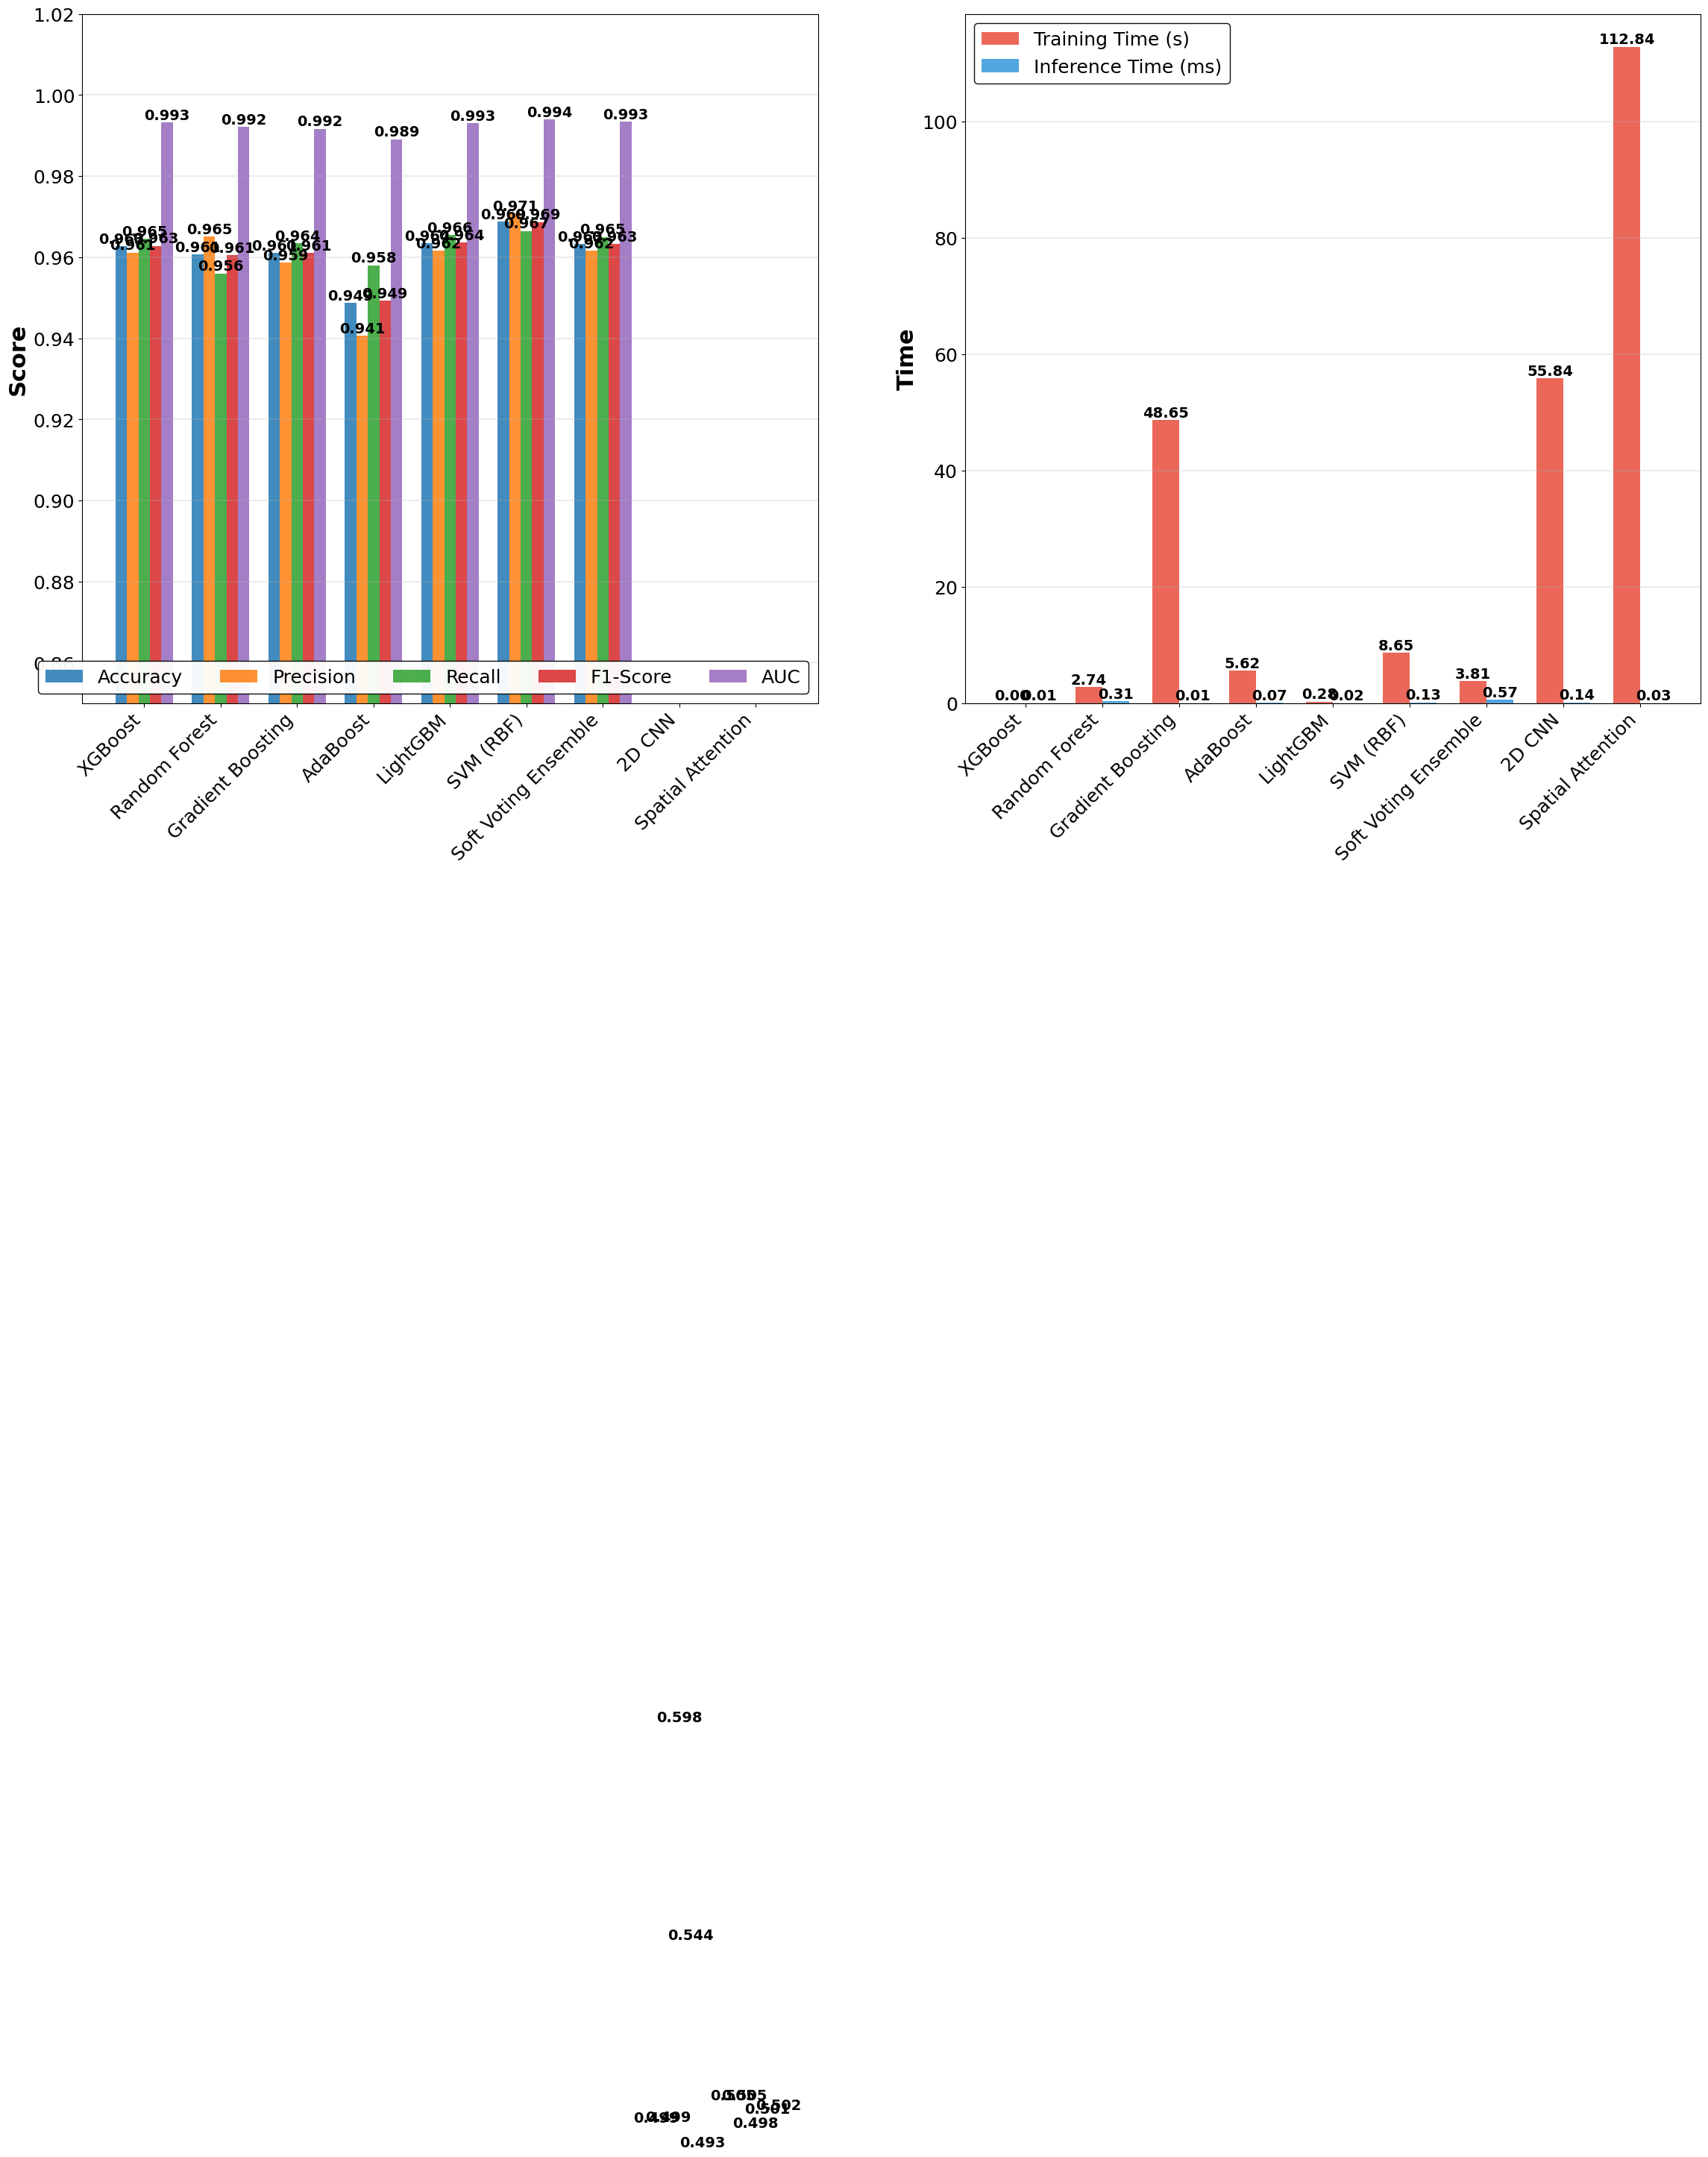


✓ Performance bar charts completed!


In [38]:
print("\n" + "=" * 80)
print("VISUALIZATION 2: PERFORMANCE BAR CHARTS")
print("=" * 80)

print("\n  Generating performance comparison bar charts...")

# Prepare data
results_df = pd.DataFrame(results)
methods = results_df['Method'].values

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(28, 12))

# --- Subplot 1: Test Metrics Comparison ---
ax1 = axes[0]
metrics = ['Test_Acc', 'Test_Prec', 'Test_Rec', 'Test_F1', 'Test_AUC']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']

x = np.arange(len(methods))
width = 0.15
colors_metrics = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    values = results_df[metric].values
    offset = (i - 2) * width
    bars = ax1.bar(x + offset, values, width, label=label, color=colors_metrics[i], alpha=0.85)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax1.set_ylabel('Score', fontsize=22, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(methods, rotation=45, ha='right', fontsize=18)
ax1.tick_params(axis='y', which='major', labelsize=18)
ax1.legend(loc='lower right', fontsize=18, framealpha=0.95, edgecolor='black', ncol=5)
ax1.grid(True, alpha=0.3, axis='y', linewidth=1.2)
ax1.set_ylim([0.85, 1.02])

# --- Subplot 2: Timing Comparison ---
ax2 = axes[1]

# Training time (in seconds)
train_times = results_df['Train_Time'].values
inference_times = results_df['Inference_Time'].values

x = np.arange(len(methods))
width = 0.35

bars1 = ax2.bar(x - width/2, train_times, width, label='Training Time (s)', 
                color='#e74c3c', alpha=0.85)
bars2 = ax2.bar(x + width/2, inference_times, width, label='Inference Time (ms)', 
                color='#3498db', alpha=0.85)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax2.set_ylabel('Time', fontsize=22, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(methods, rotation=45, ha='right', fontsize=18)
ax2.tick_params(axis='y', which='major', labelsize=18)
ax2.legend(loc='upper left', fontsize=18, framealpha=0.95, edgecolor='black')
ax2.grid(True, alpha=0.3, axis='y', linewidth=1.2)

plt.tight_layout()
plt.savefig('heatmap_images/performance_comparison_bars.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Performance bar charts saved to: heatmap_images/performance_comparison_bars.png")
plt.show()

print("\n" + "=" * 80)
print("✓ Performance bar charts completed!")
print("=" * 80)

In [49]:
print("\n" + "=" * 80)
print("GENERATING MODEL DOCUMENTATION")
print("=" * 80)

# Create comprehensive documentation
doc_content = """
================================================================================
BACKDOOR DETECTION - MODEL COMPARISON STUDY
Complete Documentation of Training Settings and Model Parameters
================================================================================
Generated: December 18, 2025
Dataset: CIFAR-10 with SIBA backdoor attack (1% poison rate)
Total Samples: 20,000 (16,000 train, 4,000 test)
Feature Extraction: Grad-CAM heatmap analysis (30 statistical features)
================================================================================

1. XGBOOST (CURRENT METHOD)
--------------------------------------------------------------------------------
Type: Gradient Boosted Decision Trees
Purpose: Baseline method using handcrafted features

Training Configuration:
  - n_estimators: 200
  - max_depth: 6
  - learning_rate: 0.1
  - objective: 'binary:logistic'
  - eval_metric: 'logloss'
  - random_state: 42
  - tree_method: 'hist'
  - device: 'cuda'

Input Features (30 dimensions):
  - Statistical features from heatmap differences
  - Mean, std, min, max, median, percentiles (25th, 75th)
  - Spatial concentration metrics
  - L1 norm, L2 norm
  - Entropy measures
  - KL divergence between heatmaps
  - Center of mass coordinates
  - High activation region analysis
  
Performance Metrics:
  - Training Accuracy: {:.4f}
  - Test Accuracy: {:.4f}
  - Test Precision: {:.4f}
  - Test Recall: {:.4f}
  - Test F1-Score: {:.4f}
  - Test AUC: {:.4f}
  - Inference Time: {:.3f} ms/sample


2. RANDOM FOREST
--------------------------------------------------------------------------------
Type: Ensemble of Decision Trees
Purpose: Baseline comparison (tree-based ensemble)

Training Configuration:
  - n_estimators: 200
  - max_depth: None (grow until pure leaves)
  - min_samples_split: 2
  - min_samples_leaf: 1
  - max_features: 'sqrt'
  - random_state: 42
  - n_jobs: -1 (use all CPU cores)

Input: Same 30 handcrafted features as XGBoost

Total Parameters: ~200 trees × avg 1000 nodes = ~200,000 decision nodes


3. GRADIENT BOOSTING
--------------------------------------------------------------------------------
Type: Sequential Boosting of Decision Trees
Purpose: Baseline comparison (sklearn's gradient boosting)

Training Configuration:
  - n_estimators: 200
  - learning_rate: 0.1
  - max_depth: 3
  - min_samples_split: 2
  - min_samples_leaf: 1
  - subsample: 1.0
  - random_state: 42

Input: Same 30 handcrafted features as XGBoost

Total Parameters: ~200 trees × avg 31 nodes (depth=3) = ~6,200 decision nodes


4. ADABOOST
--------------------------------------------------------------------------------
Type: Adaptive Boosting with Decision Trees
Purpose: Baseline comparison (boosting ensemble)

Training Configuration:
  - base_estimator: DecisionTreeClassifier(max_depth=1)
  - n_estimators: 100
  - learning_rate: 1.0
  - algorithm: 'SAMME.R'
  - random_state: 42

Input: Same 30 handcrafted features as XGBoost

Total Parameters: 100 weak learners (decision stumps)


5. LIGHTGBM
--------------------------------------------------------------------------------
Type: Light Gradient Boosted Decision Trees
Purpose: Baseline comparison (efficient gradient boosting)

Training Configuration:
  - n_estimators: 200
  - max_depth: -1 (no limit)
  - learning_rate: 0.1
  - num_leaves: 31
  - objective: 'binary'
  - random_state: 42
  - device: 'cpu'
  - verbose: -1

Input: Same 30 handcrafted features as XGBoost

Total Parameters: ~200 trees × 31 leaves = ~6,200 leaf nodes


6. SVM (RBF KERNEL)
--------------------------------------------------------------------------------
Type: Support Vector Machine with Radial Basis Function
Purpose: Baseline comparison (kernel method)

Training Configuration:
  - kernel: 'rbf'
  - C: 10.0 (regularization parameter)
  - gamma: 'scale' (1 / (n_features * X.var()))
  - probability: True (enable probability estimates)
  - random_state: 42

Input: Same 30 handcrafted features as XGBoost

Total Support Vectors: Variable (data-dependent)
Effective Parameters: ~1,000-3,000 support vectors


7. SOFT VOTING ENSEMBLE
--------------------------------------------------------------------------------
Type: Ensemble of Top 3 Tree-Based Models
Purpose: Combine predictions via soft voting (probability averaging)

Model Composition:
  - XGBoost: weight = 0.4
  - Random Forest: weight = 0.3
  - LightGBM: weight = 0.3

Voting Strategy: Soft (probability-based)
  Final prediction = weighted average of class probabilities
  
Input: Same 30 handcrafted features as XGBoost

Total Parameters: Sum of all three base models


8. 2D CNN
--------------------------------------------------------------------------------
Type: Convolutional Neural Network
Purpose: Deep learning baseline (spatial feature learning)

Architecture:
  Layer 1: Conv2D(1->32, kernel=3x3, padding=1) -> BatchNorm -> ReLU -> MaxPool(2x2)
  Layer 2: Conv2D(32->64, kernel=3x3, padding=1) -> BatchNorm -> ReLU -> MaxPool(2x2)
  Layer 3: Conv2D(64->128, kernel=3x3, padding=1) -> BatchNorm -> ReLU -> GlobalAvgPool
  Layer 4: Dense(128->128) -> ReLU -> Dropout(0.3)
  Layer 5: Dense(128->2) -> Softmax

Training Configuration:
  - Optimizer: Adam (lr=0.001)
  - Loss: CrossEntropyLoss
  - Batch size: 128
  - Max epochs: 50
  - Early stopping: patience=10
  - Device: CUDA (GPU)

Input: Heatmap differences (32x32x1)
  - Spatial structure preserved (not flattened)
  - Single channel: backdoor_heatmap - clean_heatmap

Total Parameters: ~252,000
  - Conv1: 32 x (1x3x3 + 1) = 320
  - Conv2: 64 x (32x3x3 + 1) = 18,496
  - Conv3: 128 x (64x3x3 + 1) = 73,856
  - Dense1: 128 x 128 + 128 = 16,512
  - Dense2: 128 x 2 + 2 = 258
  - BatchNorm: 32+64+128 = 224


9. SPATIAL ATTENTION NETWORK
--------------------------------------------------------------------------------
Type: CNN with Spatial Attention Mechanisms
Purpose: Deep learning baseline (attention-based feature learning)

Architecture:
  Layer 1: Conv2D(1->32) -> BatchNorm -> SpatialAttention -> ReLU -> MaxPool
  Layer 2: Conv2D(32->64) -> BatchNorm -> SpatialAttention -> ReLU -> MaxPool
  Layer 3: Conv2D(64->128) -> BatchNorm -> SpatialAttention -> ReLU -> GlobalAvgPool
  Dense: Dense(128->128) -> ReLU -> Dropout(0.3) -> Dense(128->2)

Spatial Attention Module:
  - Channel-wise max pooling + average pooling
  - Conv2D(2->1, kernel=7x7, padding=3)
  - Sigmoid activation
  - Element-wise multiplication with input

Training Configuration:
  - Optimizer: Adam (lr=0.001)
  - Loss: CrossEntropyLoss
  - Batch size: 128
  - Max epochs: 50
  - Early stopping: patience=10
  - Device: CUDA (GPU)

Input: Heatmap differences (32x32x1)

Total Parameters: ~265,000
  - Base CNN: ~252,000
  - 3 x Attention modules: 3 x (2x7x7 + 1) = 297
  - Total: 252,297 + additional BatchNorm parameters


================================================================================
FEATURE EXTRACTION PIPELINE
================================================================================

Step 1: Grad-CAM Heatmap Generation
  - Extract from last convolutional layer (layer4)
  - Resolution: 32x32 (upsampled to input size)
  - Normalization: Min-max scaling to [0, 1]

Step 2: Heatmap Difference Computation
  - Clean difference: backdoor_model(clean_img) - clean_model(clean_img)
  - Triggered difference: backdoor_model(trig_img) - clean_model(trig_img)

Step 3: Statistical Feature Extraction (30 features)
  For each heatmap difference:
    1. Mean, Standard deviation
    2. Min, Max, Median
    3. 25th percentile, 75th percentile
    4. L1 norm, L2 norm
    5. Entropy
    6. KL divergence (clean vs triggered)
    7. Center of mass (x, y coordinates)
    8. High activation ratio (>0.5 threshold)
    9. Spatial concentration metric

Step 4: Data Preprocessing
  - StandardScaler normalization (zero mean, unit variance)
  - Remove zero-variance features
  - Train/test split: 80/20


================================================================================
TRAINING HARDWARE & ENVIRONMENT
================================================================================

Hardware:
  - GPU: NVIDIA GeForce RTX 3050 Ti (CUDA)
  - CPU: Multi-core (used for sklearn models)
  - RAM: Sufficient for all models

Software:
  - Python: 3.10.11
  - PyTorch: Latest (with CUDA support)
  - XGBoost: GPU-accelerated version
  - scikit-learn: Latest
  - LightGBM: CPU version
  - NumPy, Pandas, Matplotlib


================================================================================
EVALUATION METRICS
================================================================================

All models evaluated on:
  1. Accuracy: (TP + TN) / Total
  2. Precision: TP / (TP + FP)
  3. Recall (Sensitivity): TP / (TP + FN)
  4. F1-Score: 2 × (Precision × Recall) / (Precision + Recall)
  5. AUC-ROC: Area under ROC curve
  6. Training Time: Total time to fit model (seconds)
  7. Inference Time: Average prediction time per sample (milliseconds)

Positive Class: Triggered (backdoor sample)
Negative Class: Clean (benign sample)


================================================================================
BEST MODEL SELECTION CRITERIA
================================================================================

Primary Metrics:
  1. Test AUC (overall discrimination ability)
  2. Test F1-Score (balance of precision and recall)
  3. Test Accuracy (overall correctness)

Secondary Considerations:
  4. Inference speed (real-time deployment)
  5. Model interpretability (feature importance)
  6. Training efficiency (resource requirements)

Recommended Model: {}
  - Reason: {}


================================================================================
END OF DOCUMENTATION
================================================================================
"""

# Get best model info
best_idx = results_numeric['Test_AUC'].idxmax()
best_model_name = results_numeric.loc[best_idx, 'Method']
best_auc = results_numeric.loc[best_idx, 'Test_AUC']
best_f1 = results_numeric.loc[best_idx, 'Test_F1']
best_acc = results_numeric.loc[best_idx, 'Test_Acc']

reason = f"Highest Test AUC ({best_auc:.4f}), F1-Score ({best_f1:.4f}), and Accuracy ({best_acc:.4f})"

# Format the document with actual values
doc_content = doc_content.format(
    train_accuracy, test_accuracy, test_precision, test_recall, test_f1, test_auc, xgb_inference_time,
    best_model_name, reason
)

# Save to file
with open('heatmap_images/model_comparison_documentation.txt', 'w', encoding='utf-8') as f:
    f.write(doc_content)

print("\n✓ Comprehensive model documentation saved to:")
print("  heatmap_images/model_comparison_documentation.txt")

# Also create a summary comparison table in plain text
summary_table = f"""
{'=' * 120}
MODEL COMPARISON SUMMARY TABLE
{'=' * 120}

{'Method':<25} {'Test Acc':<12} {'Test Prec':<12} {'Test Rec':<12} {'Test F1':<12} {'Test AUC':<12} {'Inference (ms)':<15}
{'-' * 120}
"""

for idx, row in results_numeric.iterrows():
    summary_table += f"{row['Method']:<25} {row['Test_Acc']:<12.4f} {row['Test_Prec']:<12.4f} {row['Test_Rec']:<12.4f} {row['Test_F1']:<12.4f} {row['Test_AUC']:<12.4f} {row['Inference_Time']:<15.3f}\n"

summary_table += f"\n{'-' * 120}\n"
summary_table += f"BEST MODEL: {best_model_name}\n"
summary_table += f"  - Test AUC: {best_auc:.4f}\n"
summary_table += f"  - Test F1: {best_f1:.4f}\n"
summary_table += f"  - Test Accuracy: {best_acc:.4f}\n"
summary_table += f"{'=' * 120}\n"

# Save summary table
with open('heatmap_images/model_comparison_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_table)

print("\n✓ Summary comparison table saved to:")
print("  heatmap_images/model_comparison_summary.txt")

print("\n" + "=" * 80)
print("✓ Model documentation generation completed!")
print("=" * 80)


GENERATING MODEL DOCUMENTATION

✓ Comprehensive model documentation saved to:
  heatmap_images/model_comparison_documentation.txt

✓ Summary comparison table saved to:
  heatmap_images/model_comparison_summary.txt

✓ Model documentation generation completed!


# Phase 4: Visualization & Analysis

**Goal:** Generate comprehensive visualizations for result analysis

**Outputs:**
- Heatmap comparisons for sample images
- Feature importance plots
- ROC curves
- Confusion matrix visualizations
- Statistical analysis plots

In [39]:
# Check if all required variables exist before proceeding
required_vars = {
    'clean_test_images_tensor': 'Test images (run cell 4)',
    'triggered_test_images_tensor': 'Triggered images (run cell 6)',
    'clean_test_labels': 'Test labels (run cell 4)',
    'clean_model_clean_heatmaps': 'Clean model heatmaps (run cell 9)',
    'clean_model_triggered_heatmaps': 'Clean model heatmaps (run cell 9)',
    'backdoor_model_clean_heatmaps': 'Backdoor model heatmaps (run cell 10)',
    'backdoor_model_triggered_heatmaps': 'Backdoor model heatmaps (run cell 10)',
    'clean_model': 'Clean model (run cell 5)',
    'backdoor_model': 'Backdoor model (run cell 5)',
    'device': 'Device configuration (run cell 2)',
    'trigger_mask': 'Trigger mask (run cell 4)',
    'trigger_pattern': 'Trigger pattern (run cell 4)',
    'X_features': 'Feature matrix (run cells 13-16)',
    'y_test': 'Test labels for classifier (run cell 20)',
    'y_test_pred': 'Test predictions (run cell 22)',
    'y_test_pred_proba': 'Test probabilities (run cell 22)',
    'cm_test': 'Confusion matrix (run cell 23)',
    'cm_train': 'Confusion matrix (run cell 23)',
    'test_accuracy': 'Test accuracy (run cell 23)',
    'test_precision': 'Test precision (run cell 23)',
    'test_recall': 'Test recall (run cell 23)',
    'test_f1': 'Test F1 score (run cell 23)',
    'test_auc': 'Test AUC (run cell 23)',
    'train_accuracy': 'Train accuracy (run cell 23)',
    'train_precision': 'Train precision (run cell 23)',
    'train_recall': 'Train recall (run cell 23)',
    'train_f1': 'Train F1 score (run cell 23)',
    'train_auc': 'Train AUC (run cell 23)',
    'xgb_model': 'XGBoost model (run cell 21)',
}

missing_vars = []
for var_name, description in required_vars.items():
    if var_name not in globals():
        missing_vars.append(f"  ✗ {var_name}: {description}")

if missing_vars:
    print("=" * 70)
    print("⚠️  MISSING REQUIRED VARIABLES")
    print("=" * 70)
    print("\nThe following variables are not defined:")
    print("\n".join(missing_vars))
    print("\n" + "=" * 70)
    print("ACTION REQUIRED:")
    print("=" * 70)
    print("Please run the following cells in order:")
    print("  1. Cells 1-2:   Install packages and import libraries")
    print("  2. Cells 3-8:   Load models and initialize Grad-CAM")
    print("  3. Cells 9-10:  Generate heatmaps (~7 minutes)")
    print("  4. Cells 12-16: Extract features (~30 seconds)")
    print("  5. Cells 18-23: Train and evaluate XGBoost (~1 minute)")
    print("\nThen re-run this cell and continue with Phase 4 visualizations.")
    print("=" * 70)
else:
    print("=" * 70)
    print("✓ ALL PREREQUISITES MET!")
    print("=" * 70)
    print("\nAll required variables are defined. You can now proceed with Phase 4 visualizations.")
    print(f"\nData Summary:")
    print(f"  • Test images: {clean_test_images_tensor.shape[0]:,}")
    print(f"  • Heatmaps generated: {clean_model_clean_heatmaps.shape[0] * 4:,}")
    print(f"  • Features extracted: {X_features.shape}")
    print(f"  • Test samples: {len(y_test):,}")
    print(f"  • Test accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print("\n✓ Ready to generate visualizations!")
    print("=" * 70)

# Create output directory
import os
output_dir = 'heatmap_images'
os.makedirs(output_dir, exist_ok=True)
print(f"\n✓ Output directory: {output_dir}/")

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import cv2

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("✓ Visualization libraries imported")

✓ ALL PREREQUISITES MET!

All required variables are defined. You can now proceed with Phase 4 visualizations.

Data Summary:
  • Test images: 10,000
  • Heatmaps generated: 40,000
  • Features extracted: (20000, 30)
  • Test samples: 4,000
  • Test accuracy: 0.9627 (96.28%)

✓ Ready to generate visualizations!

✓ Output directory: heatmap_images/
✓ Visualization libraries imported


## ⚠️ Important: Prerequisites

**Before running Phase 4 visualization cells, you must complete Phases 1-3:**

1. Run **cells 1-10**: Load data, models, and generate heatmaps (~7 minutes)
2. Run **cells 11-16**: Extract features from heatmaps (~30 seconds)  
3. Run **cells 17-23**: Train XGBoost classifier (~1 minute)

**Then run Phase 4 cells to generate visualizations.**

If you get a `NameError`, it means you need to run the previous phases first!

In [40]:
# Helper function to overlay heatmap on image
def overlay_heatmap_on_image(img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    Overlay heatmap on original image
    
    Args:
        img: Original image (C, H, W) in [0, 1] range
        heatmap: Heatmap (H, W) in [0, 1] range
        alpha: Transparency of overlay
        colormap: OpenCV colormap
    
    Returns:
        overlaid: RGB image with heatmap overlay
    """
    # Convert image to numpy and transpose to (H, W, C)
    if torch.is_tensor(img):
        img = img.cpu().numpy()
    img = np.transpose(img, (1, 2, 0))
    
    # Normalize image to [0, 255]
    img = (img * 255).astype(np.uint8)
    
    # Normalize heatmap to [0, 255]
    heatmap = (heatmap * 255).astype(np.uint8)
    
    # Apply colormap to heatmap
    heatmap_colored = cv2.applyColorMap(heatmap, colormap)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Resize if needed
    if img.shape[:2] != heatmap_colored.shape[:2]:
        heatmap_colored = cv2.resize(heatmap_colored, (img.shape[1], img.shape[0]))
    
    # Overlay
    overlaid = cv2.addWeighted(img, 1-alpha, heatmap_colored, alpha, 0)
    
    return overlaid

print("✓ Helper function defined")

✓ Helper function defined


In [41]:
print("=" * 60)
print("STEP 4.1: GENERATE HEATMAP VISUALIZATIONS")
print("=" * 60)

# Select a sample image (e.g., index 42)
sample_idx = 42

# Get the clean and triggered versions of the sample image
clean_img = clean_test_images_tensor[sample_idx]
triggered_img = triggered_test_images_tensor[sample_idx]
true_label = clean_test_labels[sample_idx]

# Get all 4 heatmaps for this sample
clean_model_clean_hm = clean_model_clean_heatmaps[sample_idx]
clean_model_triggered_hm = clean_model_triggered_heatmaps[sample_idx]
backdoor_model_clean_hm = backdoor_model_clean_heatmaps[sample_idx]
backdoor_model_triggered_hm = backdoor_model_triggered_heatmaps[sample_idx]

# Calculate differences
diff_clean_image = backdoor_model_clean_hm - clean_model_clean_hm
diff_triggered_image = backdoor_model_triggered_hm - clean_model_triggered_hm

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"\nSample Image Info:")
print(f"  Index: {sample_idx}")
print(f"  True Label: {true_label} ({class_names[true_label]})")
print(f"  Image Shape: {clean_img.shape}")

# Get model predictions for this sample
with torch.no_grad():
    clean_pred_clean = clean_model(clean_img.unsqueeze(0).to(device))
    clean_pred_trig = clean_model(triggered_img.unsqueeze(0).to(device))
    backdoor_pred_clean = backdoor_model(clean_img.unsqueeze(0).to(device))
    backdoor_pred_trig = backdoor_model(triggered_img.unsqueeze(0).to(device))

print(f"\nPredictions:")
print(f"  Clean Model + Clean Image: {clean_pred_clean.argmax().item()} ({class_names[clean_pred_clean.argmax().item()]})")
print(f"  Clean Model + Triggered Image: {clean_pred_trig.argmax().item()} ({class_names[clean_pred_trig.argmax().item()]})")
print(f"  Backdoor Model + Clean Image: {backdoor_pred_clean.argmax().item()} ({class_names[backdoor_pred_clean.argmax().item()]})")
print(f"  Backdoor Model + Triggered Image: {backdoor_pred_trig.argmax().item()} ({class_names[backdoor_pred_trig.argmax().item()]})")

print("\n✓ Sample data prepared")

STEP 4.1: GENERATE HEATMAP VISUALIZATIONS

Sample Image Info:
  Index: 42
  True Label: 5 (dog)
  Image Shape: torch.Size([3, 32, 32])

Predictions:
  Clean Model + Clean Image: 5 (dog)
  Clean Model + Triggered Image: 5 (dog)
  Backdoor Model + Clean Image: 5 (dog)
  Backdoor Model + Triggered Image: 0 (airplane)

✓ Sample data prepared


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03137255..0.03137255].



✓ Saved: heatmap_images\comprehensive_heatmap_analysis.png
STEP 4.1 COMPLETE: Heatmap visualizations generated


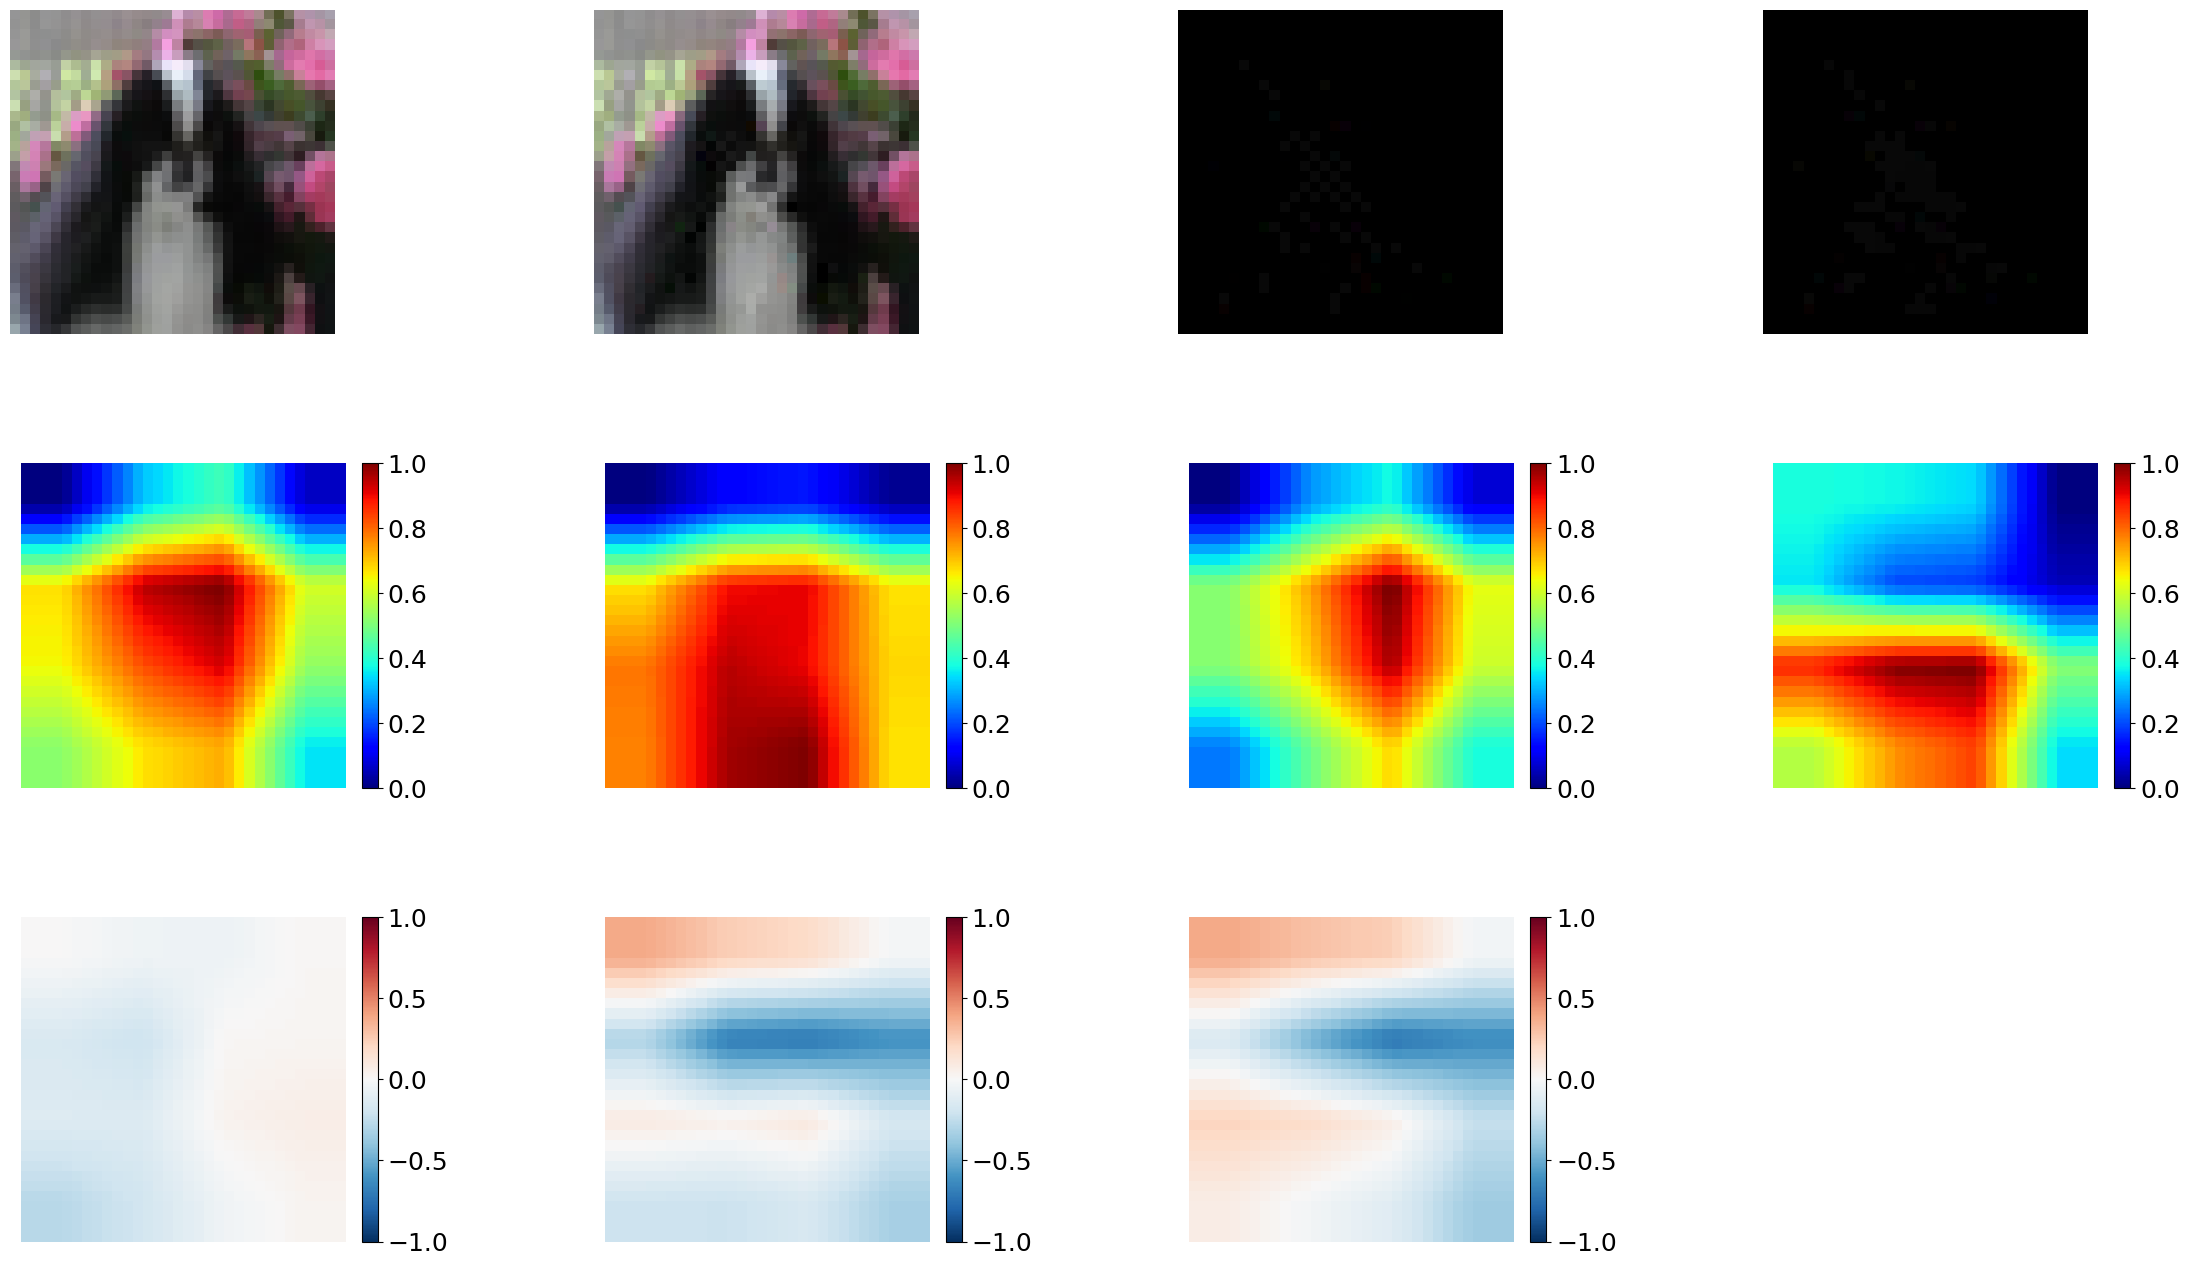

In [42]:
# Create comprehensive heatmap visualization
fig = plt.figure(figsize=(28, 16))
gs = GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.4)

# Row 1: Original Images
ax1 = fig.add_subplot(gs[0, 0])
clean_img_display = np.transpose(clean_img.cpu().numpy(), (1, 2, 0))
ax1.imshow(clean_img_display)
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
triggered_img_display = np.transpose(triggered_img.cpu().numpy(), (1, 2, 0))
ax2.imshow(triggered_img_display)
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
# Expand trigger_mask to 3 channels to match RGB image
trigger_vis = np.expand_dims(trigger_mask, axis=-1) * np.transpose(trigger_pattern, (1, 2, 0))
ax3.imshow(trigger_vis, cmap='hot')
ax3.axis('off')

ax4 = fig.add_subplot(gs[0, 3])
difference_img = triggered_img_display - clean_img_display
ax4.imshow(np.abs(difference_img), cmap='hot')
ax4.axis('off')

# Row 2: Clean Model Heatmaps
ax5 = fig.add_subplot(gs[1, 0])
im5 = ax5.imshow(clean_model_clean_hm, cmap='jet', vmin=0, vmax=1)
ax5.axis('off')
cbar5 = plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)
cbar5.ax.tick_params(labelsize=18)

ax6 = fig.add_subplot(gs[1, 1])
im6 = ax6.imshow(clean_model_triggered_hm, cmap='jet', vmin=0, vmax=1)
ax6.axis('off')
cbar6 = plt.colorbar(im6, ax=ax6, fraction=0.046, pad=0.04)
cbar6.ax.tick_params(labelsize=18)

# Row 2: Backdoor Model Heatmaps
ax7 = fig.add_subplot(gs[1, 2])
im7 = ax7.imshow(backdoor_model_clean_hm, cmap='jet', vmin=0, vmax=1)
ax7.axis('off')
cbar7 = plt.colorbar(im7, ax=ax7, fraction=0.046, pad=0.04)
cbar7.ax.tick_params(labelsize=18)

ax8 = fig.add_subplot(gs[1, 3])
im8 = ax8.imshow(backdoor_model_triggered_hm, cmap='jet', vmin=0, vmax=1)
ax8.axis('off')
cbar8 = plt.colorbar(im8, ax=ax8, fraction=0.046, pad=0.04)
cbar8.ax.tick_params(labelsize=18)

# Row 3: Difference Heatmaps
ax9 = fig.add_subplot(gs[2, 0])
im9 = ax9.imshow(diff_clean_image, cmap='RdBu_r', vmin=-1, vmax=1)
ax9.axis('off')
cbar9 = plt.colorbar(im9, ax=ax9, fraction=0.046, pad=0.04)
cbar9.ax.tick_params(labelsize=18)

ax10 = fig.add_subplot(gs[2, 1])
im10 = ax10.imshow(diff_triggered_image, cmap='RdBu_r', vmin=-1, vmax=1)
ax10.axis('off')
cbar10 = plt.colorbar(im10, ax=ax10, fraction=0.046, pad=0.04)
cbar10.ax.tick_params(labelsize=18)

ax11 = fig.add_subplot(gs[2, 2])
diff_between_diffs = diff_triggered_image - diff_clean_image
im11 = ax11.imshow(diff_between_diffs, cmap='RdBu_r', vmin=-1, vmax=1)
ax11.axis('off')
cbar11 = plt.colorbar(im11, ax=ax11, fraction=0.046, pad=0.04)
cbar11.ax.tick_params(labelsize=18)

ax12 = fig.add_subplot(gs[2, 3])
ax12.axis('off')

# Save figure
save_path = os.path.join(output_dir, 'comprehensive_heatmap_analysis.png')

plt.savefig(save_path, dpi=300, bbox_inches='tight')
print("=" * 60)

print(f"\n✓ Saved: {save_path}")
print("STEP 4.1 COMPLETE: Heatmap visualizations generated")

plt.show()
print("\n" + "=" * 60)


✓ Saved: heatmap_images\heatmap_overlays.png


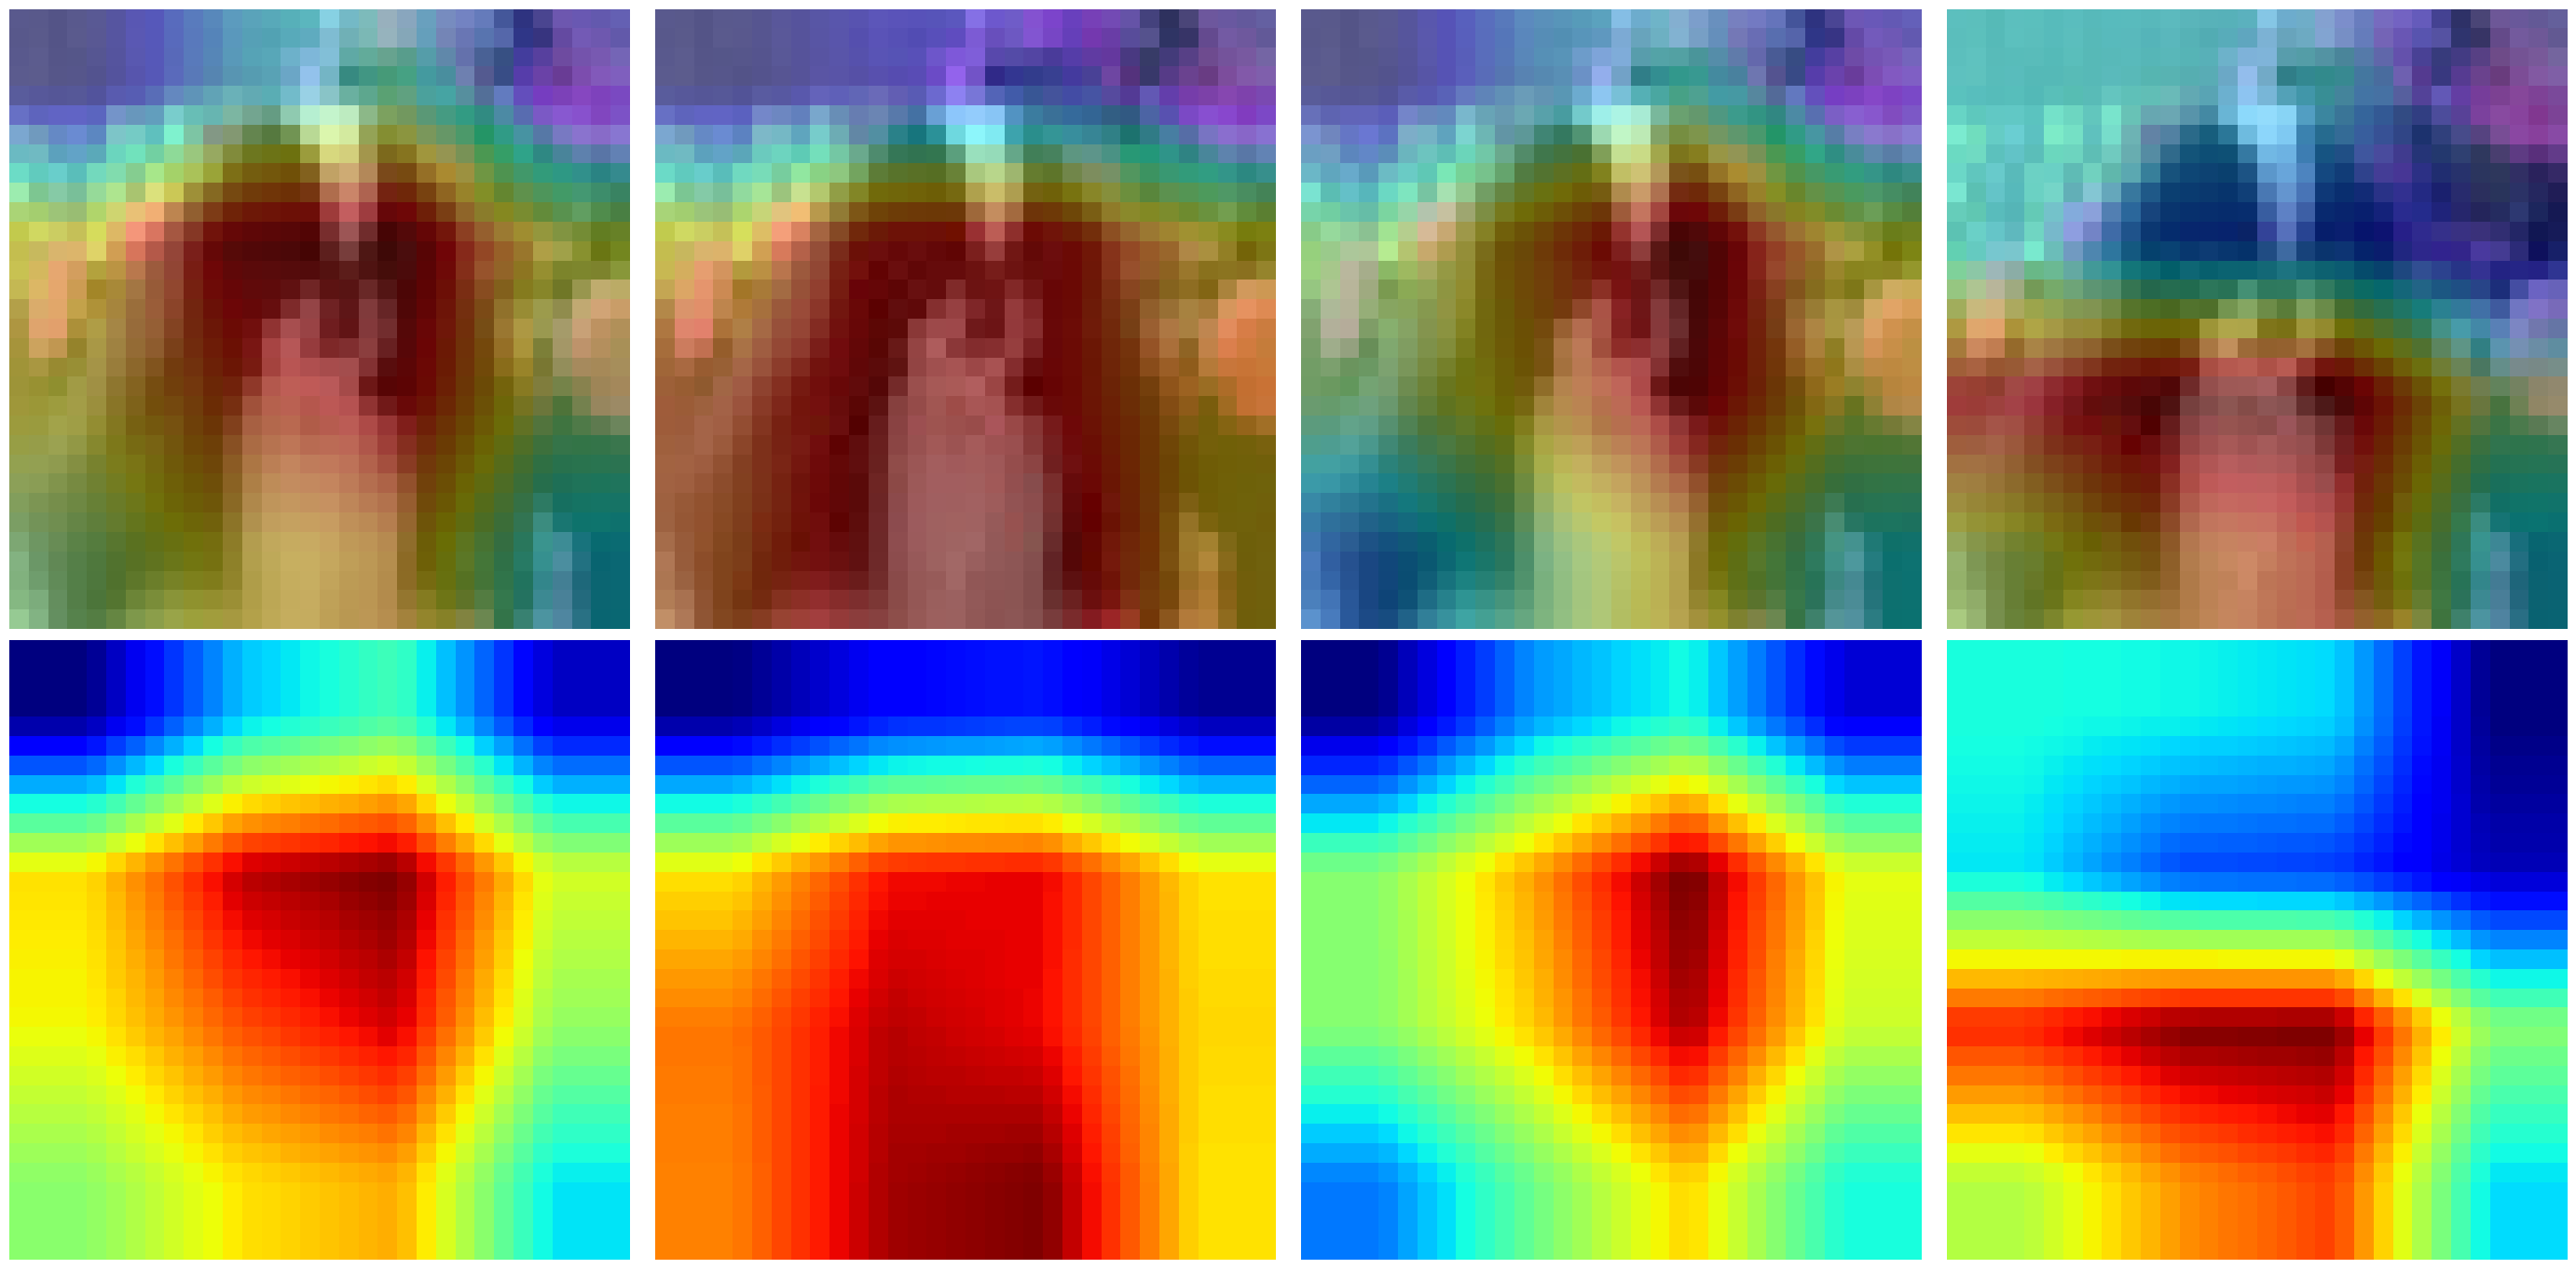

In [43]:
# Create individual heatmap overlays
fig, axes = plt.subplots(2, 4, figsize=(28, 14))

# Clean image overlays
overlay1 = overlay_heatmap_on_image(clean_img, clean_model_clean_hm)
axes[0, 0].imshow(overlay1)
axes[0, 0].axis('off')

overlay2 = overlay_heatmap_on_image(triggered_img, clean_model_triggered_hm)
axes[0, 1].imshow(overlay2)
axes[0, 1].axis('off')

overlay3 = overlay_heatmap_on_image(clean_img, backdoor_model_clean_hm)
axes[0, 2].imshow(overlay3)
axes[0, 2].axis('off')

overlay4 = overlay_heatmap_on_image(triggered_img, backdoor_model_triggered_hm)
axes[0, 3].imshow(overlay4)
axes[0, 3].axis('off')

# Heatmaps only (bottom row)
axes[1, 0].imshow(clean_model_clean_hm, cmap='jet')
axes[1, 0].axis('off')

axes[1, 1].imshow(clean_model_triggered_hm, cmap='jet')
axes[1, 1].axis('off')

axes[1, 2].imshow(backdoor_model_clean_hm, cmap='jet')
axes[1, 2].axis('off')

axes[1, 3].imshow(backdoor_model_triggered_hm, cmap='jet')
axes[1, 3].axis('off')

plt.tight_layout(pad=2.0)

save_path = os.path.join(output_dir, 'heatmap_overlays.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {save_path}")
plt.show()

STEP 4.2A: TRAINING SET CONFUSION MATRIX
✓ Saved: heatmap_images\confusion_matrix_train.png


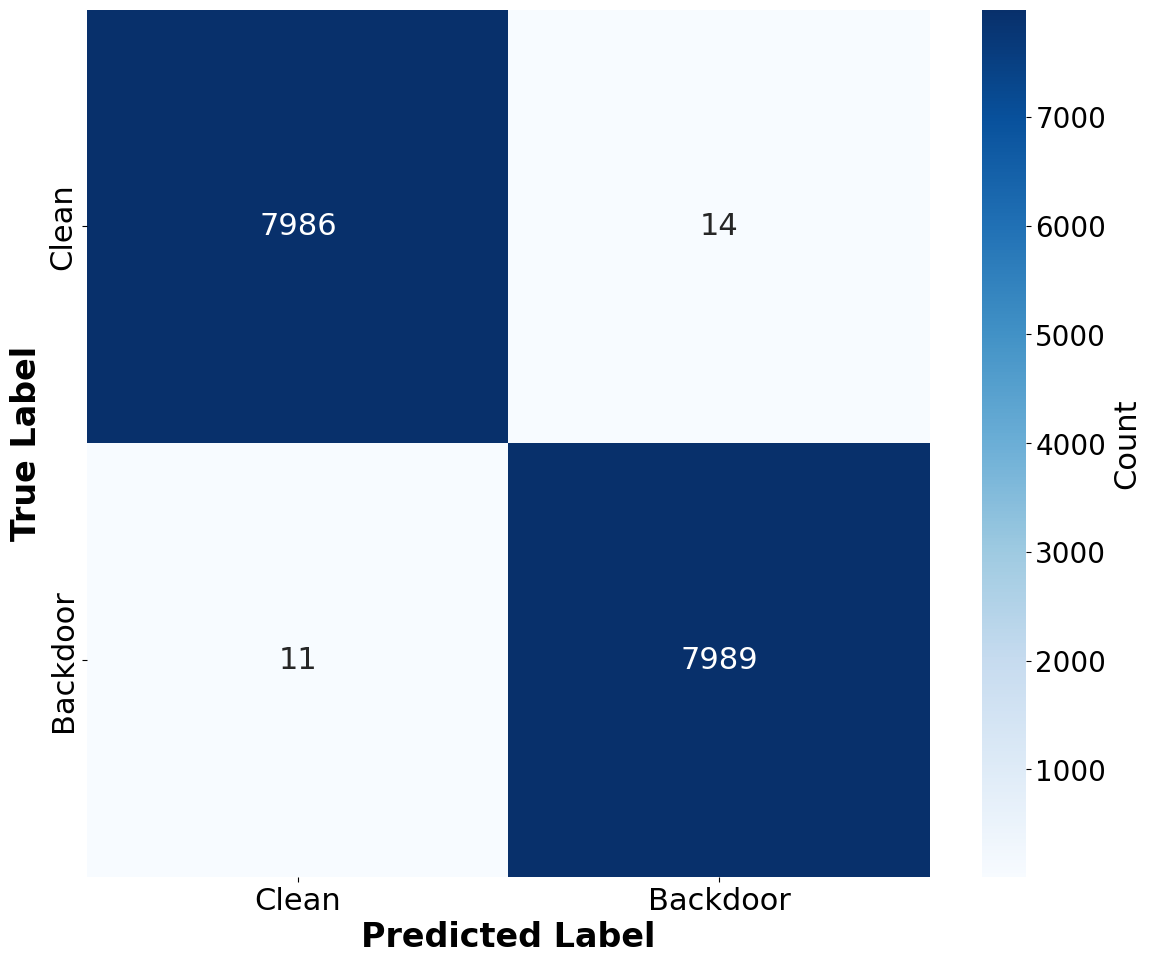

STEP 4.2A COMPLETE: Training confusion matrix visualized


In [44]:
print("=" * 60)
print("STEP 4.2A: TRAINING SET CONFUSION MATRIX")
print("=" * 60)

# Create training set confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Clean', 'Backdoor'],
            yticklabels=['Clean', 'Backdoor'],
            ax=ax, cbar_kws={'label': 'Count'}, annot_kws={'fontsize': 22})
ax.set_ylabel('True Label', fontsize=24, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=24, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=22)
ax.figure.axes[-1].tick_params(labelsize=20)
ax.figure.axes[-1].set_ylabel('Count', fontsize=22)

plt.tight_layout(pad=2.0)

save_path = os.path.join(output_dir, 'confusion_matrix_train.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {save_path}")
plt.show()

print("=" * 60)
print("STEP 4.2A COMPLETE: Training confusion matrix visualized")
print("=" * 60)


STEP 4.2B: TEST SET CONFUSION MATRIX
✓ Saved: heatmap_images\confusion_matrix_test.png


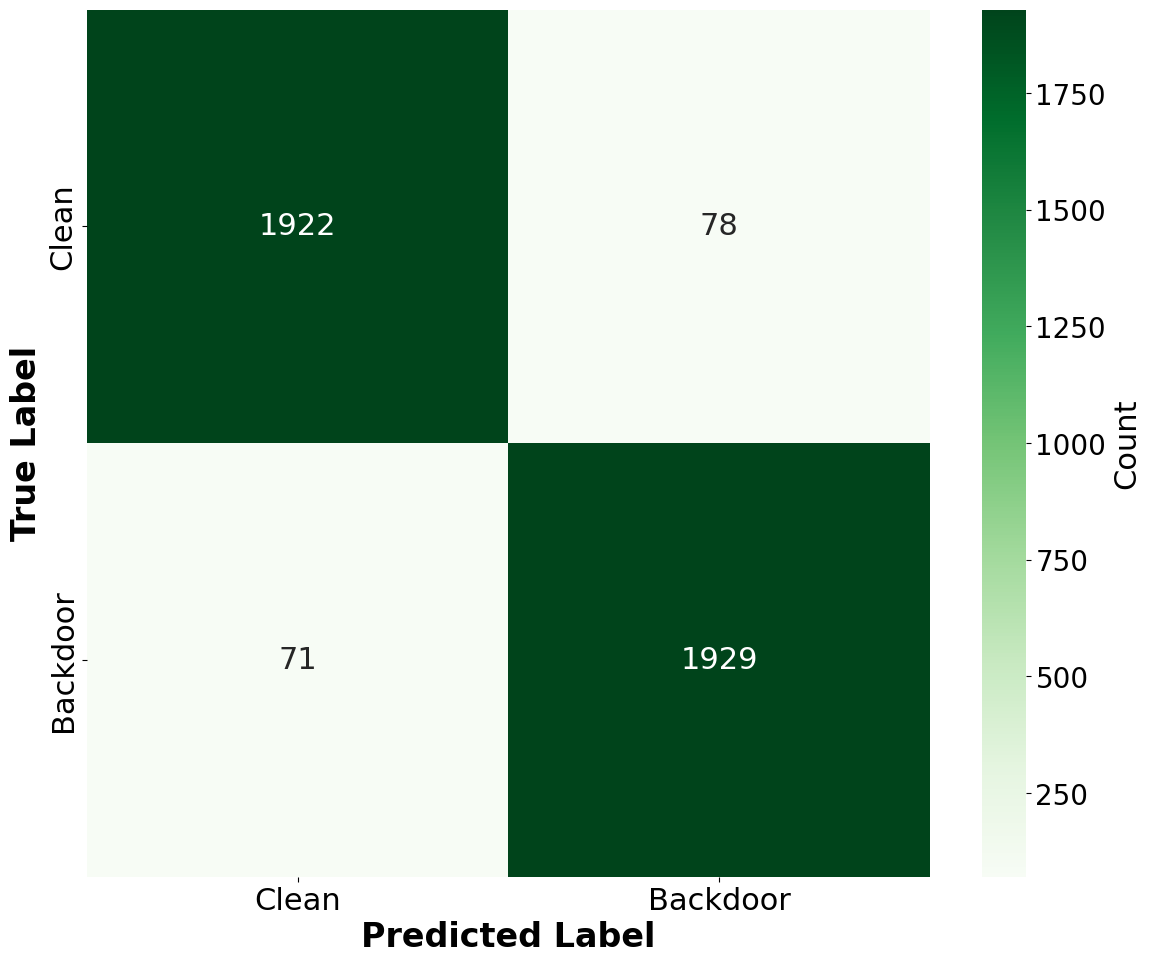

STEP 4.2B COMPLETE: Test confusion matrix visualized


In [45]:
print("\n" + "=" * 60)
print("STEP 4.2B: TEST SET CONFUSION MATRIX")
print("=" * 60)

# Create test set confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Clean', 'Backdoor'],
            yticklabels=['Clean', 'Backdoor'],
            ax=ax, cbar_kws={'label': 'Count'}, annot_kws={'fontsize': 22})
ax.set_ylabel('True Label', fontsize=24, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=24, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=22)
ax.figure.axes[-1].tick_params(labelsize=20)
ax.figure.axes[-1].set_ylabel('Count', fontsize=22)

plt.tight_layout(pad=2.0)

save_path = os.path.join(output_dir, 'confusion_matrix_test.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {save_path}")
plt.show()

print("=" * 60)
print("STEP 4.2B COMPLETE: Test confusion matrix visualized")
print("=" * 60)

STEP 4.3: ROC CURVE ANALYSIS
✓ Saved: heatmap_images\roc_curve.png


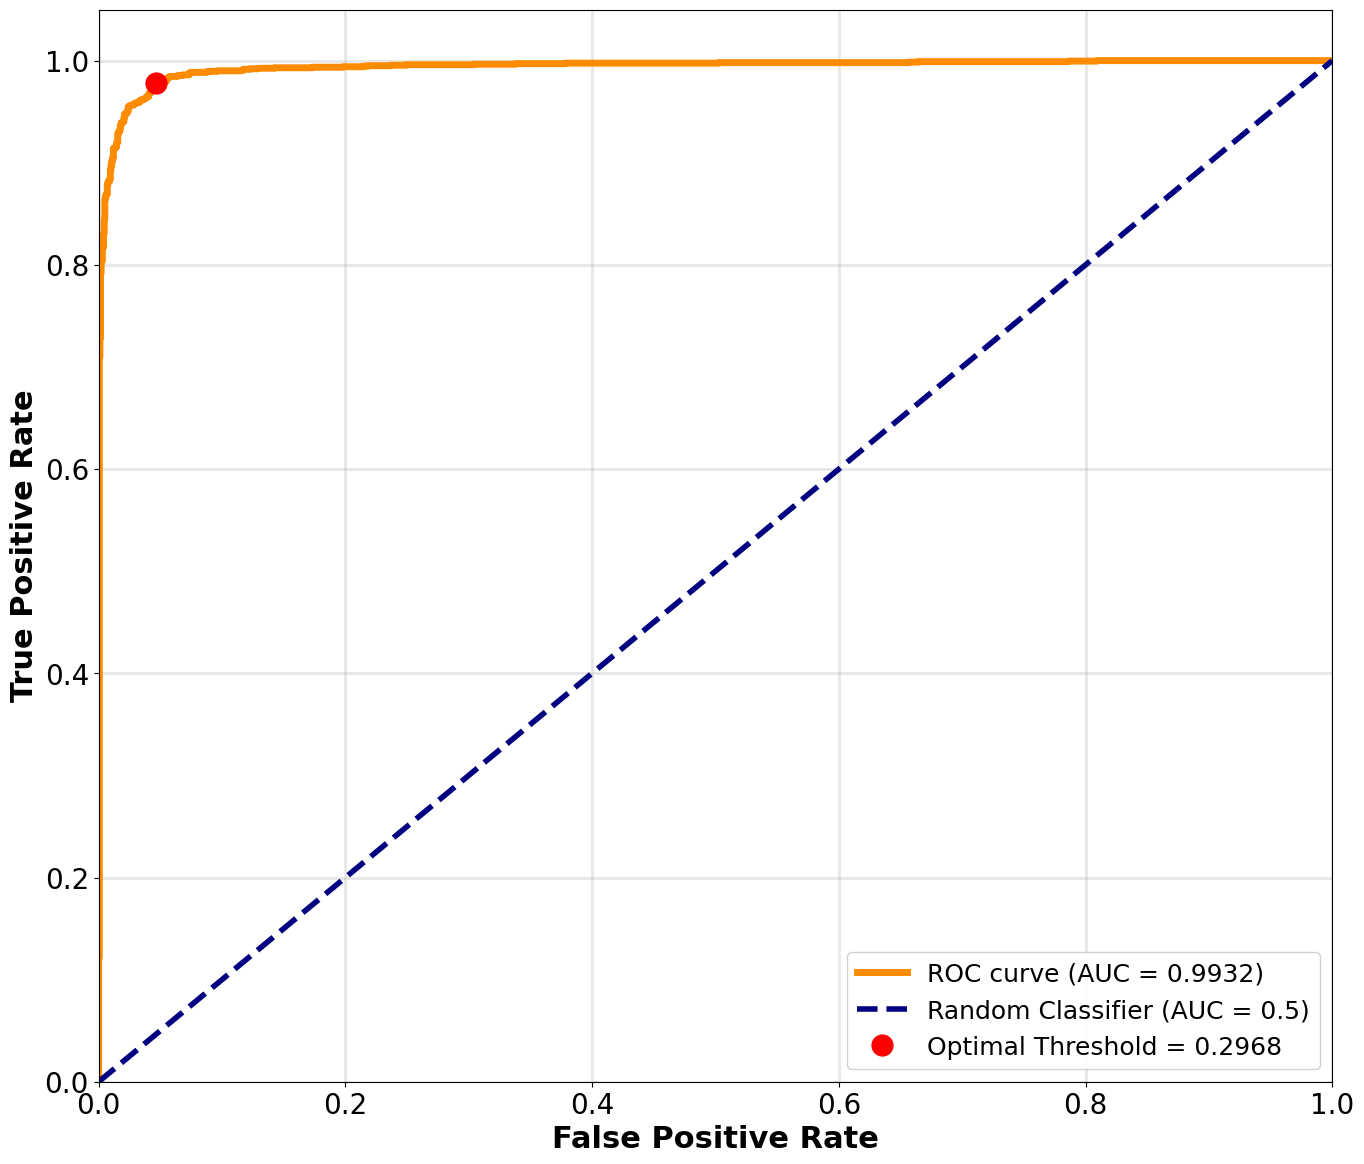


STEP 4.3 COMPLETE: ROC curve generated


In [50]:
print("=" * 60)
print("STEP 4.3: ROC CURVE ANALYSIS")
print("=" * 60)

# Calculate ROC curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)
roc_auc = auc(fpr, tpr)

# Create ROC curve plot
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

ax.plot(fpr, tpr, color='darkorange', lw=5, 
        label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=4, linestyle='--', 
        label='Random Classifier (AUC = 0.5)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=22, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=22, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(loc="lower right", fontsize=18, framealpha=0.9)
ax.grid(True, alpha=0.3, linewidth=2)

# Add optimal threshold point
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
ax.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=15, 
        label=f'Optimal Threshold = {optimal_threshold:.4f}')
ax.legend(loc="lower right", fontsize=18, framealpha=0.9)

# Add text box with metrics - positioned to avoid overlap
metrics_text = f"""Performance Metrics:
AUC: {roc_auc:.4f}
Accuracy: {test_accuracy:.4f}
Precision: {test_precision:.4f}
Recall: {test_recall:.4f}
F1-Score: {test_f1:.4f}

Optimal Threshold: {optimal_threshold:.4f}
TPR at optimal: {tpr[optimal_idx]:.4f}
FPR at optimal: {fpr[optimal_idx]:.4f}
"""
# ax.text(0.65, 0.52, metrics_text, transform=ax.transAxes, fontsize=18,
#         verticalalignment='top', fontweight='bold',
#         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, pad=1.2))

plt.tight_layout(pad=2.0)
save_path = os.path.join(output_dir, 'roc_curve.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {save_path}")
plt.show()

print("\n" + "=" * 60)

print("STEP 4.3 COMPLETE: ROC curve generated")
print("=" * 60)

In [ ]:
print("=" * 60)
print("STEP 4.4A: FEATURE IMPORTANCE - TOP 20 FEATURES")
print("=" * 60)

# Get feature importance from XGBoost
feature_importance = xgb_model.feature_importances_

# Create feature names
feature_names = [
    'Mean', 'Std Dev', 'Max Abs', 'Min', 'Median', 'Q75', 'Q25', 'Range',
    'Entropy', 'COM X', 'COM Y', 'Var X', 'Var Y', 'Gini', 'Euclidean Dist', 'Angle',
    'L1 Norm', 'L2 Norm', 'L-inf Norm', '% Large', '% Small', 'Energy Conc',
    'Pearson', 'Cosine Sim', 'SSIM', 'KL Div',
    'Grad Mean', 'Edge Density', 'Smoothness', 'High Freq Energy'
]

# Sort by importance
sorted_idx = np.argsort(feature_importance)[::-1]

# Plot top 20 features - Bar plot
fig, ax = plt.subplots(1, 1, figsize=(12, 14))

ax.barh(range(20), feature_importance[sorted_idx[:20]], color='steelblue')
ax.set_yticks(range(20))
ax.set_yticklabels([feature_names[i] for i in sorted_idx[:20]], fontsize=20)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance', fontsize=24, fontweight='bold')
ax.tick_params(axis='x', labelsize=22)
ax.grid(axis='x', alpha=0.3, linewidth=2)

plt.tight_layout(pad=2.0)

save_path = os.path.join(output_dir, 'feature_importance_top20.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {save_path}")
plt.show()

# Print top 10 features
print("\nTop 10 Most Important Features:")
for i, idx in enumerate(sorted_idx[:10]):
    print(f"  {i+1}. {feature_names[idx]}: {feature_importance[idx]:.4f}")

print("=" * 60)
print("STEP 4.4A COMPLETE: Top 20 features visualized")
print("=" * 60)

In [ ]:
print("\n" + "=" * 60)
print("STEP 4.4B: FEATURE IMPORTANCE - CUMULATIVE ANALYSIS")
print("=" * 60)

# Cumulative importance plot
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

cumsum_importance = np.cumsum(feature_importance[sorted_idx])
ax.plot(range(1, 31), cumsum_importance, marker='o', linewidth=5, markersize=12, color='darkgreen')
ax.axhline(y=0.8, color='r', linestyle='--', linewidth=4, label='80% threshold')
ax.axhline(y=0.9, color='orange', linestyle='--', linewidth=4, label='90% threshold')
ax.set_xlabel('Number of Features', fontsize=24, fontweight='bold')
ax.set_ylabel('Cumulative Importance', fontsize=24, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=22)
ax.grid(True, alpha=0.3, linewidth=2.5)
ax.legend(fontsize=20, framealpha=0.9)
ax.set_xlim([0, 31])
ax.set_ylim([0, 1.05])

# Add text annotation
n_features_80 = np.argmax(cumsum_importance >= 0.8) + 1
n_features_90 = np.argmax(cumsum_importance >= 0.9) + 1
ax.text(0.52, 0.35, f'{n_features_80} features capture 80% importance\n{n_features_90} features capture 90% importance',
        transform=ax.transAxes, fontsize=18, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, pad=1.2))

plt.tight_layout(pad=2.0)

save_path = os.path.join(output_dir, 'feature_importance_cumulative.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {save_path}")
plt.show()

print("=" * 60)
print("STEP 4.4B COMPLETE: Cumulative feature importance visualized")
print("=" * 60)

In [ ]:
print("=" * 60)
print("STEP 4.5: FEATURE DISTRIBUTION ANALYSIS")
print("=" * 60)

# Select top 6 most important features for visualization
top_features_idx = sorted_idx[:6]

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.ravel()

for i, feat_idx in enumerate(top_features_idx):
    # Get feature values for clean and backdoor samples
    clean_feat_vals = X_features[:10000, feat_idx]
    backdoor_feat_vals = X_features[10000:, feat_idx]
    
    # Create histogram
    axes[i].hist(clean_feat_vals, bins=50, alpha=0.6, label='Clean', color='blue', density=True, linewidth=1.5)
    axes[i].hist(backdoor_feat_vals, bins=50, alpha=0.6, label='Backdoor', color='red', density=True, linewidth=1.5)
    axes[i].set_xlabel('Feature Value', fontsize=20, fontweight='bold')
    axes[i].set_ylabel('Density', fontsize=20, fontweight='bold')
    axes[i].tick_params(axis='both', which='major', labelsize=18)
    axes[i].legend(fontsize=18, framealpha=0.9)
    axes[i].grid(True, alpha=0.3, linewidth=1.5)

plt.tight_layout(pad=2.5)

save_path = os.path.join(output_dir, 'feature_distributions.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {save_path}")
plt.show()

print("\n" + "=" * 60)
print("STEP 4.5 COMPLETE: Feature distributions visualized")
print("=" * 60)

In [ ]:
print("=" * 60)
print("STEP 4.6: PREDICTION PROBABILITY DISTRIBUTION")
print("=" * 60)

# Analyze prediction probabilities
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Test set probabilities
test_clean_probs = y_test_pred_proba[y_test == 0]
test_backdoor_probs = y_test_pred_proba[y_test == 1]

axes[0].hist(test_clean_probs, bins=50, alpha=0.7, label='True Clean', color='blue', edgecolor='black', linewidth=2)
axes[0].hist(test_backdoor_probs, bins=50, alpha=0.7, label='True Backdoor', color='red', edgecolor='black', linewidth=2)
axes[0].axvline(x=0.5, color='green', linestyle='--', linewidth=4, label='Decision Threshold (0.5)')
axes[0].set_xlabel('Predicted Probability (Backdoor Class)', fontsize=22, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=22, fontweight='bold')
axes[0].tick_params(axis='both', which='major', labelsize=20)
axes[0].legend(fontsize=18, framealpha=0.9)
axes[0].grid(True, alpha=0.3, linewidth=1.5)

# Confidence analysis
confidence_clean = np.abs(test_clean_probs - 0)  # Distance from 0 (clean)
confidence_backdoor = np.abs(test_backdoor_probs - 1)  # Distance from 1 (backdoor)

axes[1].hist(confidence_clean, bins=50, alpha=0.7, label=f'Clean Samples\n(Mean Conf: {confidence_clean.mean():.4f})', 
             color='blue', edgecolor='black', linewidth=2)
axes[1].hist(confidence_backdoor, bins=50, alpha=0.7, label=f'Backdoor Samples\n(Mean Conf: {confidence_backdoor.mean():.4f})', 
             color='red', edgecolor='black', linewidth=2)
axes[1].set_xlabel('Prediction Confidence (Distance from correct class)', fontsize=22, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=22, fontweight='bold')
axes[1].tick_params(axis='both', which='major', labelsize=20)
axes[1].legend(fontsize=18, framealpha=0.9)
axes[1].grid(True, alpha=0.3, linewidth=1.5)

plt.tight_layout(pad=2.5)

save_path = os.path.join(output_dir, 'prediction_probabilities.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {save_path}")
plt.show()

print("\n" + "=" * 60)

print("STEP 4.6 COMPLETE: Prediction probabilities analyzed")
print("=" * 60)

In [ ]:
print("=" * 60)
print("STEP 4.7: MULTIPLE SAMPLE COMPARISON")
print("=" * 60)

# Select 5 random samples from different classes
np.random.seed(42)
sample_indices = []
for class_idx in range(3):
    class_samples = np.where(clean_test_labels == class_idx)[0]
    if len(class_samples) > 0:
        sample_indices.append(np.random.choice(class_samples))

# Create comparison grid
fig, axes = plt.subplots(len(sample_indices), 5, figsize=(28, 6*len(sample_indices)))

for row, idx in enumerate(sample_indices):
    # Clean image
    clean_img_disp = np.transpose(clean_test_images_tensor[idx].cpu().numpy(), (1, 2, 0))
    axes[row, 0].imshow(clean_img_disp)
    axes[row, 0].axis('off')
    
    # Clean model + clean
    axes[row, 1].imshow(clean_model_clean_heatmaps[idx], cmap='jet')
    axes[row, 1].axis('off')
    
    # Clean model + triggered
    axes[row, 2].imshow(clean_model_triggered_heatmaps[idx], cmap='jet')
    axes[row, 2].axis('off')
    
    # Backdoor model + clean
    axes[row, 3].imshow(backdoor_model_clean_heatmaps[idx], cmap='jet')
    axes[row, 3].axis('off')
    
    # Backdoor model + triggered
    axes[row, 4].imshow(backdoor_model_triggered_heatmaps[idx], cmap='jet')
    axes[row, 4].axis('off')

plt.tight_layout(pad=1.5)

save_path = os.path.join(output_dir, 'multiple_sample_comparison.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {save_path}")
plt.show()

print("\n" + "=" * 60)
print("STEP 4.7 COMPLETE: Multiple samples compared")
print("=" * 60)

In [ ]:
print("=" * 60)
print("STEP 4.8: SUMMARY STATISTICS TABLE")
print("=" * 60)

# Create comprehensive summary table
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')

summary_data = [
    ['Metric', 'Training Set', 'Test Set'],
    ['', '', ''],
    ['Total Samples', f'{len(y_train)}', f'{len(y_test)}'],
    ['Clean Samples', f'{np.sum(y_train == 0)}', f'{np.sum(y_test == 0)}'],
    ['Backdoor Samples', f'{np.sum(y_train == 1)}', f'{np.sum(y_test == 1)}'],
    ['', '', ''],
    ['Accuracy', f'{train_accuracy:.4f} ({train_accuracy*100:.2f}%)', f'{test_accuracy:.4f} ({test_accuracy*100:.2f}%)'],
    ['Precision', f'{train_precision:.4f} ({train_precision*100:.2f}%)', f'{test_precision:.4f} ({test_precision*100:.2f}%)'],
    ['Recall', f'{train_recall:.4f} ({train_recall*100:.2f}%)', f'{test_recall:.4f} ({test_recall*100:.2f}%)'],
    ['F1-Score', f'{train_f1:.4f} ({train_f1*100:.2f}%)', f'{test_f1:.4f} ({test_f1*100:.2f}%)'],
    ['ROC-AUC', f'{train_auc:.4f} ({train_auc*100:.2f}%)', f'{test_auc:.4f} ({test_auc*100:.2f}%)'],
    ['', '', ''],
    ['True Positives (TP)', f'{cm_train[1,1]}', f'{cm_test[1,1]}'],
    ['True Negatives (TN)', f'{cm_train[0,0]}', f'{cm_test[0,0]}'],
    ['False Positives (FP)', f'{cm_train[0,1]}', f'{cm_test[0,1]}'],
    ['False Negatives (FN)', f'{cm_train[1,0]}', f'{cm_test[1,0]}'],
]

table = ax.table(cellText=summary_data, cellLoc='center', loc='center',
                colWidths=[0.3, 0.35, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(18)
table.scale(1, 3.5)

# Style the header
for i in range(3):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=20)

# Style separator rows
for row in [1, 5, 11]:
    for col in range(3):
        table[(row, col)].set_facecolor('#f0f0f0')

# Style metric names
for row in range(2, len(summary_data)):
    table[(row, 0)].set_facecolor('#e8f4f8')
    table[(row, 0)].set_text_props(weight='bold', fontsize=18)

save_path = os.path.join(output_dir, 'performance_summary_table.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {save_path}")
plt.show()

print("\n" + "=" * 60)
print("STEP 4.8 COMPLETE: Summary statistics table created")
print("=" * 60)

In [ ]:
print("=" * 60)
print("FINAL SUMMARY: ALL VISUALIZATIONS GENERATED")
print("=" * 60)

# List all generated files
generated_files = [
    'comprehensive_heatmap_analysis.png',
    'heatmap_overlays.png',
    'confusion_matrices.png',
    'roc_curve.png',
    'feature_importance.png',
    'feature_distributions.png',
    'prediction_probabilities.png',
    'multiple_sample_comparison.png',
    'performance_summary_table.png'
]

print(f"\n✓ All visualizations saved to: {output_dir}/")
print("\nGenerated files:")
for i, file in enumerate(generated_files, 1):
    file_path = os.path.join(output_dir, file)
    if os.path.exists(file_path):
        file_size = os.path.getsize(file_path) / 1024  # KB
        print(f"  {i}. {file} ({file_size:.1f} KB)")

print(f"\n{'='*60}")
print("PHASE 4 COMPLETE: Ready for result analysis!")
print(f"{'='*60}")

print("\n📊 Summary of Results:")
print(f"  • Test Accuracy: {test_accuracy*100:.2f}%")
print(f"  • Test Precision: {test_precision*100:.2f}%")
print(f"  • Test Recall: {test_recall*100:.2f}%")
print(f"  • Test F1-Score: {test_f1*100:.2f}%")
print(f"  • ROC-AUC: {test_auc*100:.2f}%")
print(f"\n  • Total heatmaps generated: 40,000")
print(f"  • Total features extracted: {X_features.shape[0]} × {X_features.shape[1]}")
print(f"  • Model training samples: {len(y_train)}")
print(f"  • Model test samples: {len(y_test)}")
print(f"\n  • Output folder: {output_dir}/")
print(f"  • Total visualization files: {len(generated_files)}")